<a href="https://colab.research.google.com/github/archipelagoing/Situationion/blob/main/Copy_of_v5_Decodability_MechDiagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SituatiONION V5: Decodability Atlas

This notebook maps held-out linear decodability across situation variables, token readouts, and GPT-2 XL layers. It uses V4's frozen long-format data and hidden-state cache. Decodability is not causal necessity.

# V5- Initial idea.

**Central question: What specific components of the situation can be decoded at different depths?**

V5 would contain:

Layer-wise probes.
Agent decoding.
Recipient decoding.
Event decoding.
Causality decoding.
Temporal-relation decoding.
Polarity decoding.
Held-out-template evaluation.
Attention comparison.
PCA vs random-projection controls.
Stronger non-semantic controls if V4 identifies remaining concerns.

This is where you investigate whether the geometry from V4 actually corresponds to identifiable situation variables.

Your progression becomes:

$$ \text{V4: Where is information?} $$ $$ \downarrow $$ $$ \text{V5: What information is there?} $$

## Held-Out Linear Probes

Identity probes test only held-out templates with seen entities. Binary situation-variable probes test templates, entities, and combined holdouts. Each task reports linear, shuffled-label, random-projection, lexical, and majority controls.

# V5 — Decodability and Mechanistic Diagnostics

## Central Question

**Which situation variables are decodable from which token representations at different depths, and how does their decodability change across the network?**

V4 established that situation-sensitive geometry is distributed across GPT-2 XL rather than localized to a single privileged layer. It also showed that this geometry depends strongly on both the **situation dimension being manipulated** and the **token representation being measured**.

V5 therefore moves from measuring geometric separation to identifying the information represented by that geometry.

$$
\text{V4: Where is situation-sensitive information?}
$$

$$
\downarrow
$$

$$
\text{V5: What situation information is represented there?}
$$

## Primary Analyses

### 1. Layer × Readout Probing

Train layer-wise probes at multiple token representations rather than probing only one sentence-level representation.

Readouts should include:

* Changed token
* Event token
* Final token
* Agent/recipient token where applicable
* Mean pool as a global baseline
* Max pool as a negative/weak baseline where useful

The goal is to construct a **layer × readout × situation-variable** decodability map.

### 2. Situation-Variable Decoding

Probe separately for:

* Agent
* Recipient
* Agent/recipient role assignment
* Event/state
* Causality
* Polarity
* Temporal relation

These variables should be treated as separate prediction problems rather than collapsed into a single "situation" label.

### 3. Held-Out Generalization

Probe performance must be evaluated on held-out templates or structural families.

Random train/test sentence splits are insufficient because a probe could exploit lexical or template-specific regularities rather than situation information.

Where possible, evaluate:

* Held-out templates
* Held-out lexical items
* Held-out situation combinations

This asks whether the representation encodes a generalizable situation variable rather than memorizing the construction used to express it.

### 4. Probe Controls

For every probe, compare against appropriate controls:

* Majority/chance baseline
* Label-shuffled probe
* Lexical/surface-feature baseline
* Random-projection representation control
* Where appropriate, embedding-layer or early-layer baseline

Probe complexity should be kept deliberately limited, beginning with linear probes.

The purpose is to measure information that is readily available in the representation, not information that a powerful classifier can reconstruct.

### 5. V4-Guided Predictions

V5 should preregister several predictions based on V4.

**P1 — Token specificity**

Situation variables should generally be more decodable from semantically relevant token representations than from global pooled representations.

**P2 — Changed-token early availability**

Variables directly expressed by the manipulated token may already be decodable in very early layers.

This would distinguish **local lexical availability** from later contextual integration.

**P3 — Event-token contextual development**

Event/state information should show increasing decodability at the Event-token representation through early and middle layers, consistent with the depth-dependent trajectory observed in V4.

**P4 — Final-token integration**

Multiple situation variables may become decodable from the Final-token representation, consistent with contextual information becoming distributed beyond its original token location.

**P5 — Dimension-specific trajectories**

Agent/recipient, event/state, causality, polarity, and temporal relations should not exhibit identical layer-wise decodability curves.

**P6 — Temporal uncertainty**

Because V4 found weak temporal separation, temporal decoding is an important diagnostic rather than an expected positive result.

Failure to decode temporal relations would itself constrain the broader situation-model hypothesis.

### 6. Geometry–Decodability Correspondence

Compare V4 geometric separation with V5 probe performance.

For each:

$$
(\text{dimension},\text{readout},\text{layer})
$$

ask whether stronger counterfactual-vs-paraphrase separation predicts greater decodability of the corresponding situation variable.

This directly tests whether the geometry identified in V4 corresponds to identifiable semantic information.

## Secondary Mechanistic Diagnostics

### Attention Analysis

Compare attention patterns only as a secondary diagnostic.

Attention should not by itself be interpreted as evidence that a component stores or causally uses situation information.

Ask whether changes in decodability coincide with changes in information flow between situation-relevant token positions.

### PCA vs Random Projection

Retain the random-projection comparison from V4 as a visualization control.

PCA should be treated as descriptive visualization rather than primary evidence.

The primary quantitative evidence in V5 should come from held-out decoding performance and its controls.

## Interpretation Boundary

V5 tests **decodability**, not causal necessity.

Successful decoding establishes that information about a situation variable is available in a representation under the probe's assumptions. It does not establish that GPT-2 XL itself uses that information to produce its predictions.

That distinction is reserved for V6:

$$
\text{V4: Where is information?}
$$

$$
\downarrow
$$

$$
\text{V5: What information is there?}
$$

$$
\downarrow
$$

$$
\text{V6: Does the model causally use it?}
$$

## V5 Goal

Produce a controlled map of:

$$
\boxed{
\text{Situation Variable}
\times
\text{Token Readout}
\times
\text{Layer}
\rightarrow
\text{Decodability}
}
$$

The central V5 result should therefore not be a single "best layer."

It should be a **decodability atlas showing what information is available where, and how that availability changes through the network.**


# 1. Setup and inputs
   Load data/v5_probe_examples.csv, define output paths, seeds, all 48 layers, the target variables, and the six token readouts. Load the cached V4 GPT-2 XL hidden states from:
results/layer_curves/gpt2xl_hidden_states.pt


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

ARTIFACT_DIR = Path(
    "/content/drive/MyDrive/Fall26/Coding/SituationionArtifacts"
)
DATA_PATH = ARTIFACT_DIR / "v5_probe_examples.csv"
CACHE_PATH = ARTIFACT_DIR / "gpt2xl_hidden_states.pt"

if DATA_PATH.exists():
    print(f"Data path found: {DATA_PATH}")
else:
    print(f"Data path not found: {DATA_PATH}")

Data path found: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_probe_examples.csv


In [ ]:
!ls -lh /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts


total 2.9G
-rw------- 1 root root 124K Sep  4 00:13 candidate_triples.csv
-rw------- 1 root root 2.9G Sep  4 00:40 gpt2xl_hidden_states.pt
-rw------- 1 root root 124K Sep  4 00:13 matched_triples.csv
drwx------ 2 root root 4.0K Sep  4 18:25 v5_decodability
-rw------- 1 root root 223K Sep  4 00:13 v5_probe_examples.csv


In [ ]:
# AFTER mounting Drive, BEFORE sklearn imports

%load_ext cuml.accel
%env CUML_ACCEL_LOG_LEVEL=info


env: CUML_ACCEL_LOG_LEVEL=info


In [ ]:
import cuml
print("RAPIDS cuML version:", cuml.__version__)

RAPIDS cuML version: 26.02.000


In [ ]:
import re
import numpy as np
import pandas as pd
import torch
import hashlib
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.random_projection import GaussianRandomProjection
from sklearn.preprocessing import StandardScaler

print("scikit-learn version:", sklearn.__version__)

ROOT = Path.cwd()

scikit-learn version: 1.6.1


In [ ]:
def stable_probe_seed(
    task,
    readout,
    layer
):

    key = (
        f"{SEED}|"
        f"{task}|"
        f"{readout}|"
        f"{layer}"
    )

    digest = hashlib.sha256(
        key.encode("utf-8")
    ).digest()

    return int.from_bytes(
        digest[:4],
        "little"
    )

In [ ]:
# from joblib import Parallel, delayed

# def probe_score(x_train, y_train, x_test, y_test):
#     if len(set(y_train)) < 2 or len(set(y_test)) < 2: return np.nan
#     probe = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)

#     # Scale the data to prevent convergence warnings
#     scaler = StandardScaler()
#     x_train_scaled = scaler.fit_transform(x_train)
#     x_test_scaled = scaler.transform(x_test)

#     return balanced_accuracy_score(y_test, probe.fit(x_train_scaled, y_train).predict(x_test_scaled))

# def eligible_splits(task, data):
#     return ('test_template',) if task in {'agent_identity', 'recipient_identity'} else tuple(split for split in ('test_template', 'test_entity', 'test_both') if (data.split == split).any())

In [ ]:
# DATA_PATH = ROOT / 'data' / 'v5_probe_examples.csv'
# CACHE_PATH = ROOT / 'results' / 'layer_curves' / 'gpt2xl_hidden_states.pt'

OUTPUT_DIR = ARTIFACT_DIR / "v5_decodability"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED, LAYERS = 7, range(48)
rng = np.random.default_rng(SEED)
TASKS = {'agent_identity': ('semantic_agent', 'agent_identity_eligible'), 'recipient_identity': ('semantic_recipient', 'recipient_identity_eligible'), 'role_assignment': ('role_assignment', 'role_assignment_eligible'), 'event_state': ('event_state', 'event_state_eligible'), 'cause_holder_role': ('cause_holder_role', 'cause_holder_role_eligible'), 'polarity': ('polarity', 'polarity_eligible'), 'temporal_relation': ('temporal_relation', 'temporal_relation_eligible')}
READOUTS = ('changed_token', 'event_token', 'final_token', 'agent_recipient', 'mean_pool', 'max_pool')
if not DATA_PATH.exists(): raise FileNotFoundError('Run python3 structural_controls.py first.')
if not CACHE_PATH.exists(): raise FileNotFoundError('Copy gpt2xl_hidden_states.pt from V4 into results/layer_curves/.')
probe_examples = pd.read_csv(DATA_PATH)
cache = torch.load(CACHE_PATH, map_location='cpu', weights_only=False)
tokenizer, RUNS = cache['tokenizer'], cache['runs']
print(f'Loaded {len(probe_examples)} sentences and {len(RUNS)} cached triples.')


Loaded 900 sentences and 300 cached triples.


# 2. Readout extraction
   Write functions that return a representation for one sentence at one layer:
   - Changed-token hidden state
   - Event-token hidden state
   - Final-token hidden state
   - Ordered agent/recipient representation
   - Mean pool
   - Max pool
The long-format CSV supplies triple_id, variant, semantic role labels, and eligibility flags; the hidden-state cache supplies the actual tensors.


In [ ]:
EVENT = {'agent_recipient': ('gave', 'gave', 'gave'), 'cause': ('called', 'called', 'called'), 'temporal': ('cleaned', 'cleaned', 'cleaned'), 'polarity': ('repair', 'mend', 'fix'), 'event_state': ('carried', 'transported', 'dropped')}
CHANGED = {'temporal': ('after', 'once', 'before'), 'polarity': ('repair', 'mend', 'not'), 'event_state': ('carried', 'transported', 'dropped')}
def token_position(text, surface):
    matches = list(re.finditer(r'(?<![a-zA-Z])' + re.escape(surface) + r'(?![a-zA-Z])', text, re.I))
    if not matches: return None # Return None if surface is not found
    return len(tokenizer.encode(text[:matches[-1].end()], add_special_tokens=False)) - 1
def readout_vector(row, layer, readout):
    run = RUNS[row.triple_id][row.variant]; hidden = run['hidden_states'][layer + 1]
    index = ('base', 'paraphrase', 'counterfactual').index(row.variant)
    if readout == 'mean_pool': return hidden.mean(0).numpy()
    if readout == 'max_pool': return hidden.max(0).values.numpy()
    if readout == 'final_token': return hidden[-1].numpy()
    if readout == 'event_token':
        pos = token_position(run['text'], EVENT[row.manipulation][index])
        if pos is None: return None # Handle case where token is not found
        return hidden[pos].numpy()
    if readout == 'changed_token':
        surface = row.semantic_recipient if row.manipulation == 'agent_recipient' and row.variant == 'counterfactual' else (row.semantic_agent if row.manipulation in {'agent_recipient', 'cause'} else CHANGED[row.manipulation][index])
        pos = token_position(run['text'], surface)
        if pos is None: return None # Handle case where token is not found
        return hidden[pos].numpy()
    # For 'agent_recipient' readout
    agent_pos = token_position(run['text'], row.semantic_agent)
    recipient_pos = token_position(run['text'], row.semantic_recipient)

    if agent_pos is None or recipient_pos is None:
        return None # If either agent or recipient token is not found, return None for the combined vector

    return torch.cat((hidden[agent_pos], hidden[recipient_pos])).numpy()
test_vector_result = readout_vector(probe_examples.iloc[0], 0, 'final_token')
if test_vector_result is not None:
    print('Readout extraction ready:', test_vector_result.shape)
else:
    print('Readout extraction ready: Test vector could not be extracted.')


Readout extraction ready: (1600,)


In [ ]:
# =============================================================================
# V3.5 / V4.5 COMMON PROBE UTILITIES
#
# Shared scoring and split utilities for the optimized decodability pipeline.
# =============================================================================

from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.random_projection import GaussianRandomProjection


def eligible_splits(task, data):
    """
    Return the held-out splits that are valid for a given probing task.
    """

    if task in {"agent_identity", "recipient_identity"}:
        return ("test_template",)

    return tuple(
        split
        for split in ("test_template", "test_entity", "test_both")
        if (data["split"] == split).any()
    )


def fit_probe(x_train, y_train):
    """
    Fit scaler + class-balanced logistic regression ONCE.

    Returns:
        scaler, probe

    Returns (None, None) if the training labels do not contain
    at least two classes.
    """

    y_train = np.asarray(y_train)

    if len(np.unique(y_train)) < 2:
        return None, None

    if sparse.issparse(x_train):
        scaler = StandardScaler(with_mean=False)
    else:
        scaler = StandardScaler()

    x_train_scaled = scaler.fit_transform(x_train)

    probe = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    )

    probe.fit(
        x_train_scaled,
        y_train
    )

    return scaler, probe


def evaluate_probe(
    scaler,
    probe,
    x_test,
    y_test
):
    """
    Evaluate an already-fitted probe on a held-out test matrix.
    """

    if scaler is None or probe is None:
        return np.nan

    y_test = np.asarray(y_test)

    if len(np.unique(y_test)) < 2:
        return np.nan

    x_test_scaled = scaler.transform(
        x_test
    )

    predictions = probe.predict(
        x_test_scaled
    )

    return balanced_accuracy_score(
        y_test,
        predictions
    )

# 3. Held-out linear probes
   For each valid combination of:
task × readout × layer × evaluation split
fit a class-balanced logistic-regression probe on split == "dev" and evaluate separately on:
- test_template
- test_entity
- test_both
Use balanced accuracy. Identity tasks should use only held-out templates with known entity labels. Do not run identity classification on unseen entity names.


In [ ]:
# =============================================================================
# V3.5 STEP 1: BUILD REPRESENTATION MATRIX CACHE
#
# Instead of storing hundreds of thousands of individual vectors,
# build one dense matrix for each readout × layer combination:
#
#     representation_cache[(readout, layer)]
#
# Matrix rows correspond directly to probe_examples.index.
#
# This eliminates repeated Python list construction and np.stack()
# during every probe fit.
# =============================================================================

representation_cache = {}

N_EXAMPLES = len(probe_examples)

total_rep_jobs = (
    len(READOUTS)
    * len(LAYERS)
)

print(
    f"Building {total_rep_jobs:,} representation matrices "
    f"from {N_EXAMPLES:,} examples..."
)


for readout, layer in tqdm(
    [
        (readout, layer)
        for readout in READOUTS
        for layer in LAYERS
    ],
    desc="Representation matrices",
    unit="matrix"
):

    vectors = []
    valid_mask = []

    for row in probe_examples.itertuples(
        index=False
    ):

        vec = readout_vector(
            row,
            layer,
            readout
        )

        if vec is None:
            valid_mask.append(False)
            vectors.append(None)

        else:
            valid_mask.append(True)
            vectors.append(
                np.asarray(
                    vec,
                    dtype=np.float32
                )
            )


    # ---------------------------------------------------------
    # Find representation dimensionality
    # ---------------------------------------------------------

    first_valid = next(
        (
            vec
            for vec in vectors
            if vec is not None
        ),
        None
    )

    if first_valid is None:

        representation_cache[
            (readout, layer)
        ] = {
            "X": None,
            "valid": np.asarray(
                valid_mask,
                dtype=bool
            )
        }

        continue


    dim = first_valid.shape[0]


    # ---------------------------------------------------------
    # Build one contiguous float32 matrix
    # ---------------------------------------------------------

    X = np.zeros(
        (N_EXAMPLES, dim),
        dtype=np.float32
    )

    for i, vec in enumerate(vectors):

        if vec is not None:
            X[i] = vec


    representation_cache[
        (readout, layer)
    ] = {
        "X": X,
        "valid": np.asarray(
            valid_mask,
            dtype=bool
        )
    }


print(
    f"Finished building "
    f"{len(representation_cache):,} representation matrices."
)

Building 288 representation matrices from 900 examples...


Representation matrices:   0%|          | 0/288 [00:00<?, ?matrix/s]

Finished building 288 representation matrices.


In [ ]:
# =============================================================================
# V3.5 STEP 2: INDEX MAPPING + MATRIX EXTRACTION
# =============================================================================

index_to_position = {
    idx: pos
    for pos, idx in enumerate(
        probe_examples.index
    )
}


def get_representation_subset(
    indices,
    labels,
    readout,
    layer
):
    """
    Select rows from a prebuilt representation matrix while dropping
    examples for which readout_vector() was invalid.
    """

    cached = representation_cache[
        (readout, layer)
    ]

    X = cached["X"]
    valid = cached["valid"]

    if X is None:
        return None, None

    positions = np.asarray(
        [
            index_to_position[idx]
            for idx in indices
        ],
        dtype=int
    )

    labels = np.asarray(labels)

    keep = valid[positions]

    if keep.sum() == 0:
        return None, None

    return (
        X[positions[keep]],
        labels[keep]
    )

In [ ]:
# =============================================================================
# GPU ACCELERATION SANITY CHECK
# =============================================================================

import time

task = "polarity"
label, flag = TASKS[task]

data = probe_examples[
    probe_examples[flag]
].copy()

train = data.query("split == 'dev'")

x_test_gpu, y_test_gpu = get_representation_subset(
    train.index.to_numpy(),
    train[label].to_numpy(),
    READOUTS[0],
    24
)

start = time.time()

_scaler, _probe = fit_probe(
    x_test_gpu,
    y_test_gpu
)

print(
    f"Single probe fit: "
    f"{time.time() - start:.3f} sec"
)

Single probe fit: 1.593 sec


In [ ]:
# =============================================================================
# V3.5: OPTIMIZED CACHED LINEAR PROBES
#
# Major optimization:
#   Train exactly ONE probe per task × readout × layer.
#
# The fitted probe is then evaluated across every eligible held-out split.
#
# This avoids retraining an identical model separately for test_template,
# test_entity, and test_both.
# =============================================================================

linear_rows = []


# ---------------------------------------------------------
# Count unique model fits, NOT test evaluations
# ---------------------------------------------------------

total_linear_fits = (
    len(TASKS)
    * len(READOUTS)
    * len(LAYERS)
)

print(
    f"Fitting at most "
    f"{total_linear_fits:,} unique linear probes..."
)


with tqdm(
    total=total_linear_fits,
    desc="Linear probe fits",
    unit="fit"
) as pbar:

    for task, (label, flag) in TASKS.items():

        data = probe_examples[
            probe_examples[flag]
        ].copy()

        train = data.query(
            "split == 'dev'"
        )

        train_indices = train.index.to_numpy()
        y_train_raw = train[label].to_numpy()

        test_splits = eligible_splits(
            task,
            data
        )


        for readout in READOUTS:

            for layer in LAYERS:

                # =============================================================
                # BUILD DEV MATRIX ONCE
                # =============================================================

                x_train, y_train = get_representation_subset(
                    train_indices,
                    y_train_raw,
                    readout,
                    layer
                )


                # =============================================================
                # FIT ONCE
                # =============================================================

                if (
                    x_train is None
                    or len(np.unique(y_train)) < 2
                ):

                    scaler = None
                    probe = None

                else:

                    scaler, probe = fit_probe(
                        x_train,
                        y_train
                    )


                # =============================================================
                # EVALUATE ALL HELD-OUT SPLITS
                # =============================================================

                for test_split in test_splits:

                    test = data.query(
                        "split == @test_split"
                    )

                    x_test, y_test = get_representation_subset(
                        test.index.to_numpy(),
                        test[label].to_numpy(),
                        readout,
                        layer
                    )


                    if (
                        x_test is None
                        or len(np.unique(y_test)) < 2
                    ):

                        score = np.nan

                    else:

                        score = evaluate_probe(
                            scaler,
                            probe,
                            x_test,
                            y_test
                        )


                    linear_rows.append({
                        "task": task,
                        "readout": readout,
                        "layer": layer,
                        "test_split": test_split,
                        "control": "linear",
                        "score": score
                    })


                # -------------------------------------------------------------
                # Progress update
                # -------------------------------------------------------------

                pbar.set_postfix(
                    task=task,
                    readout=readout,
                    layer=layer
                )

                pbar.update(1)


linear_atlas = pd.DataFrame(
    linear_rows
)


print(
    f"\nFinished "
    f"{len(linear_atlas):,} held-out evaluations "
    f"from at most {total_linear_fits:,} fitted probes."
)

Fitting at most 2,016 unique linear probes...


Linear probe fits:   0%|          | 0/2016 [00:00<?, ?fit/s]

[2026-09-08 19:31:51.109] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:31:53.044] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:31:56.288] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:31:58.807] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:32:00.602] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:32:01.888] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:32:02.735] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:32:03.253] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)


# 4. Controls
   For every probe result, include:
   - Majority-class baseline
   - Label-shuffled logistic probe
   - TF-IDF word/bigram logistic probe
   - Random-projected hidden-state probe
   - Layer 0 as the early/embedding baseline
Store all scores in one CSV, for example:
results/v5_decodability/decodability_atlas.csv
with columns such as task, readout, layer, test_split, control, and score.


In [ ]:
# =============================================================================
# V4.5 STEP 1: PRECOMPUTE RANDOM-PROJECTION REPRESENTATIONS
#
# Random projection depends only on the hidden-state matrix, NOT on:
#   - task
#   - labels
#   - training/test split
#
# Therefore each readout × layer projection is computed exactly once.
# =============================================================================

projected_cache = {}


projection_jobs = [
    (readout, layer)
    for readout in READOUTS
    for layer in LAYERS
]


for readout, layer in tqdm(
    projection_jobs,
    desc="Random projections",
    unit="matrix"
):

    cached = representation_cache[
        (readout, layer)
    ]

    X = cached["X"]

    if X is None:

        projected_cache[
            (readout, layer)
        ] = None

        continue


    n_components = min(
        128,
        X.shape[1]
    )


    rp = GaussianRandomProjection(
        n_components=n_components,
        random_state=SEED
    )


    X_projected = rp.fit_transform(
        X
    ).astype(
        np.float32,
        copy=False
    )


    projected_cache[
        (readout, layer)
    ] = X_projected


print(
    f"Cached "
    f"{len(projected_cache):,} "
    f"random-projection matrices."
)

Random projections:   0%|          | 0/288 [00:00<?, ?matrix/s]

Cached 288 random-projection matrices.


In [ ]:
# =============================================================================
# V4.5 STEP 2: RANDOM-PROJECTION MATRIX SUBSETTING
# =============================================================================

def get_projected_subset(
    indices,
    labels,
    readout,
    layer
):

    X = projected_cache[
        (readout, layer)
    ]

    valid = representation_cache[
        (readout, layer)
    ]["valid"]

    if X is None:
        return None, None


    positions = np.asarray(
        [
            index_to_position[idx]
            for idx in indices
        ],
        dtype=int
    )

    labels = np.asarray(labels)

    keep = valid[positions]

    if keep.sum() == 0:
        return None, None


    return (
        X[positions[keep]],
        labels[keep]
    )

 V4.5: OPTIMIZED CONTROL PIPELINE

Controls:
   1. Majority-class baseline
   2. TF-IDF word/bigram logistic probe
   3. Shuffled-label hidden-state probe
   4. Random-projected hidden-state probe

 Optimizations:
   - One fit per task × readout × layer
   - Reuse each fit across every eligible test split
   - Reuse representation matrices from V3.5
   - Reuse random-projection matrices precomputed once
   - No process-based Joblib duplication

In [ ]:
# =============================================================================
# V4.5: OPTIMIZED CONTROL PIPELINE
#
# Controls:
#   1. Majority-class baseline
#   2. TF-IDF word/bigram logistic probe
#   3. Shuffled-label hidden-state probe
#   4. Random-projected hidden-state probe
#
# Optimizations:
#   - One fit per task × readout × layer
#   - Reuse each fit across every eligible test split
#   - Reuse representation matrices from V3.5
#   - Reuse random-projection matrices precomputed once
#   - No process-based Joblib duplication
# =============================================================================

control_rows = []


# =============================================================================
# A. MAJORITY + TF-IDF CONTROLS
# =============================================================================

print(
    "Running majority and lexical controls..."
)


for task, (label, flag) in tqdm(
    TASKS.items(),
    desc="Lexical controls",
    unit="task"
):

    data = probe_examples[
        probe_examples[flag]
    ].copy()

    train = data.query(
        "split == 'dev'"
    )

    y_train = train[label].to_numpy()

    test_splits = eligible_splits(
        task,
        data
    )


    # -------------------------------------------------------------------------
    # MAJORITY CLASS
    # -------------------------------------------------------------------------

    majority_class = train[
        label
    ].mode().iloc[0]


    # -------------------------------------------------------------------------
    # TF-IDF FIT ON DEV ONCE
    # -------------------------------------------------------------------------

    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        dtype=np.float32
    )


    try:

        x_train_tfidf = tfidf.fit_transform(
            train["text"]
        )

        tfidf_scaler, tfidf_probe = fit_probe(
            x_train_tfidf,
            y_train
        )

    except ValueError:

        tfidf = None
        tfidf_scaler = None
        tfidf_probe = None


    # -------------------------------------------------------------------------
    # EVALUATE EVERY TEST SPLIT
    # -------------------------------------------------------------------------

    for test_split in test_splits:

        test = data.query(
            "split == @test_split"
        )

        y_test = test[label].to_numpy()


        # =====================================================================
        # MAJORITY
        # =====================================================================

        majority_predictions = np.full(
            len(y_test),
            majority_class,
            dtype=object
        )

        majority_score = (
            balanced_accuracy_score(
                y_test,
                majority_predictions
            )
            if len(np.unique(y_test)) >= 2
            else np.nan
        )


        control_rows.append({
            "task": task,
            "readout": "majority",
            "layer": -1,
            "test_split": test_split,
            "control": "majority",
            "score": majority_score
        })


        # =====================================================================
        # TF-IDF
        # =====================================================================

        if (
            tfidf is None
            or tfidf_probe is None
        ):

            lexical_score = np.nan

        else:

            try:

                x_test_tfidf = tfidf.transform(
                    test["text"]
                )

                lexical_score = evaluate_probe(
                    tfidf_scaler,
                    tfidf_probe,
                    x_test_tfidf,
                    y_test
                )

            except ValueError:

                lexical_score = np.nan


        control_rows.append({
            "task": task,
            "readout": "lexical_tfidf",
            "layer": -1,
            "test_split": test_split,
            "control": "lexical",
            "score": lexical_score
        })

Running majority and lexical controls...


Lexical controls:   0%|          | 0/7 [00:00<?, ?task/s]

In [ ]:
# =============================================================================
# V4.5 B: SHUFFLED-LABEL + RANDOM-PROJECTION CONTROLS
#
# Fits each control once per task × readout × layer and evaluates the fitted
# model across every eligible held-out split.
# =============================================================================

total_control_fits = (
    len(TASKS)
    * len(READOUTS)
    * len(LAYERS)
)

print(
    f"Running hidden-state controls for at most "
    f"{total_control_fits:,} unique task/readout/layer combinations..."
)


with tqdm(
    total=total_control_fits,
    desc="Hidden-state controls",
    unit="representation"
) as pbar:

    for task, (label, flag) in TASKS.items():

        data = probe_examples[
            probe_examples[flag]
        ].copy()

        train = data.query(
            "split == 'dev'"
        )

        train_indices = train.index.to_numpy()
        y_train_raw = train[label].to_numpy()

        test_splits = eligible_splits(
            task,
            data
        )


        for readout in READOUTS:

            for layer in LAYERS:

                # =============================================================
                # ORIGINAL HIDDEN-STATE DEV MATRIX
                # =============================================================

                x_train, y_train = get_representation_subset(
                    train_indices,
                    y_train_raw,
                    readout,
                    layer
                )


                # =============================================================
                # SHUFFLED-LABEL CONTROL
                # =============================================================

                if (
                    x_train is None
                    or len(np.unique(y_train)) < 2
                ):

                    shuffled_scaler = None
                    shuffled_probe = None

                else:

                    local_rng = np.random.default_rng(
                        stable_probe_seed(
                            task,
                            readout,
                            layer
                        )
                    )

                    shuffled_y = local_rng.permutation(
                        y_train
                    )

                    shuffled_scaler, shuffled_probe = fit_probe(
                        x_train,
                        shuffled_y
                    )


                # =============================================================
                # RANDOM-PROJECTION DEV MATRIX
                # =============================================================

                x_train_rp, y_train_rp = get_projected_subset(
                    train_indices,
                    y_train_raw,
                    readout,
                    layer
                )


                if (
                    x_train_rp is None
                    or len(np.unique(y_train_rp)) < 2
                ):

                    rp_scaler = None
                    rp_probe = None

                else:

                    rp_scaler, rp_probe = fit_probe(
                        x_train_rp,
                        y_train_rp
                    )


                # =============================================================
                # EVALUATE BOTH CONTROLS ON ALL TEST SPLITS
                # =============================================================

                for test_split in test_splits:

                    test = data.query(
                        "split == @test_split"
                    )


                    # ---------------------------------------------------------
                    # SHUFFLED LABEL CONTROL
                    # ---------------------------------------------------------

                    x_test, y_test = get_representation_subset(
                        test.index.to_numpy(),
                        test[label].to_numpy(),
                        readout,
                        layer
                    )


                    if (
                        x_test is None
                        or len(np.unique(y_test)) < 2
                    ):

                        shuffled_score = np.nan

                    else:

                        shuffled_score = evaluate_probe(
                            shuffled_scaler,
                            shuffled_probe,
                            x_test,
                            y_test
                        )


                    control_rows.append({
                        "task": task,
                        "readout": readout,
                        "layer": layer,
                        "test_split": test_split,
                        "control": "shuffled_labels",
                        "score": shuffled_score
                    })


                    # ---------------------------------------------------------
                    # RANDOM PROJECTION CONTROL
                    # ---------------------------------------------------------

                    x_test_rp, y_test_rp = get_projected_subset(
                        test.index.to_numpy(),
                        test[label].to_numpy(),
                        readout,
                        layer
                    )


                    if (
                        x_test_rp is None
                        or len(np.unique(y_test_rp)) < 2
                    ):

                        rp_score = np.nan

                    else:

                        rp_score = evaluate_probe(
                            rp_scaler,
                            rp_probe,
                            x_test_rp,
                            y_test_rp
                        )


                    control_rows.append({
                        "task": task,
                        "readout": readout,
                        "layer": layer,
                        "test_split": test_split,
                        "control": "random_projection",
                        "score": rp_score
                    })


                pbar.set_postfix(
                    task=task,
                    readout=readout,
                    layer=layer
                )

                pbar.update(1)

Running hidden-state controls for at most 2,016 unique task/readout/layer combinations...


Hidden-state controls:   0%|          | 0/2016 [00:00<?, ?representation/s]

[2026-09-08 19:37:21.670] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:40:21.934] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-09-08 19:43:32.316] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)


In [ ]:
# =============================================================================
# C. BUILD + SAVE COMPLETE ATLAS
# =============================================================================

controls_df = pd.DataFrame(
    control_rows
)


atlas = pd.concat(
    [
        linear_atlas,
        controls_df
    ],
    ignore_index=True
)


output_file = (
    OUTPUT_DIR
    / "decodability_atlas.csv"
)


atlas.to_csv(
    output_file,
    index=False
)


print(
    f"\nSaved {len(atlas):,} total results to:"
)

print(
    output_file
)


display(
    atlas
    .groupby("control")
    .size()
    .rename("n_results")
)


Saved 14,722 total results to:
/content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/decodability_atlas.csv


,n_results
control,
lexical,17
linear,4896
majority,17
random_projection,4896
shuffled_labels,4896


In [ ]:
# =============================================================================
# V4.5 SANITY CHECK: VERIFY ALL EXPECTED CONTROLS ARE PRESENT
# =============================================================================
# Confirms that the final decodability atlas contains results for the main
# linear probe and all four control conditions:
#   - majority: chance-level/class-frequency baseline
#   - lexical: TF-IDF text-only baseline
#   - shuffled_labels: tests whether decoding survives label destruction
#   - random_projection: tests whether decoding survives generic compression
#
# Also reports the number of result rows produced by each condition.
# If a control is missing, the cell prints a warning before V5 analysis.
# =============================================================================

expected_controls = {
    "linear",
    "majority",
    "lexical",
    "shuffled_labels",
    "random_projection"
}

actual_controls = set(
    atlas["control"].dropna().unique()
)

print("Controls found:")
print(sorted(actual_controls))

missing_controls = (
    expected_controls
    - actual_controls
)

if missing_controls:
    print(
        "\nMISSING CONTROLS:",
        sorted(missing_controls)
    )
else:
    print(
        "\n✓ All expected controls are present."
    )

display(
    atlas.groupby("control")
    .size()
    .rename("n_results")
)

Controls found:
['lexical', 'linear', 'majority', 'random_projection', 'shuffled_labels']

✓ All expected controls are present.


,n_results
control,
lexical,17
linear,4896
majority,17
random_projection,4896
shuffled_labels,4896


# 5. Results and interpretation
   Create heatmaps with:
   - Rows: readouts
   - Columns: layers
   - Separate panels: situation variables
   - Values: held-out balanced accuracy
Save the atlas figures and a table of each task/readout’s peak score and layer. If results/layer_curves/heldout_layer_curves.csv is available from V4, join it by readout and layer and calculate correlations between V4 separation and V5 decodability.

Atlas rows: 14,722
Saving V5 outputs to: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability


,n_results
control,
lexical,17
linear,4896
majority,17
random_projection,4896
shuffled_labels,4896


/tmp/ipykernel_8718/743392799.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


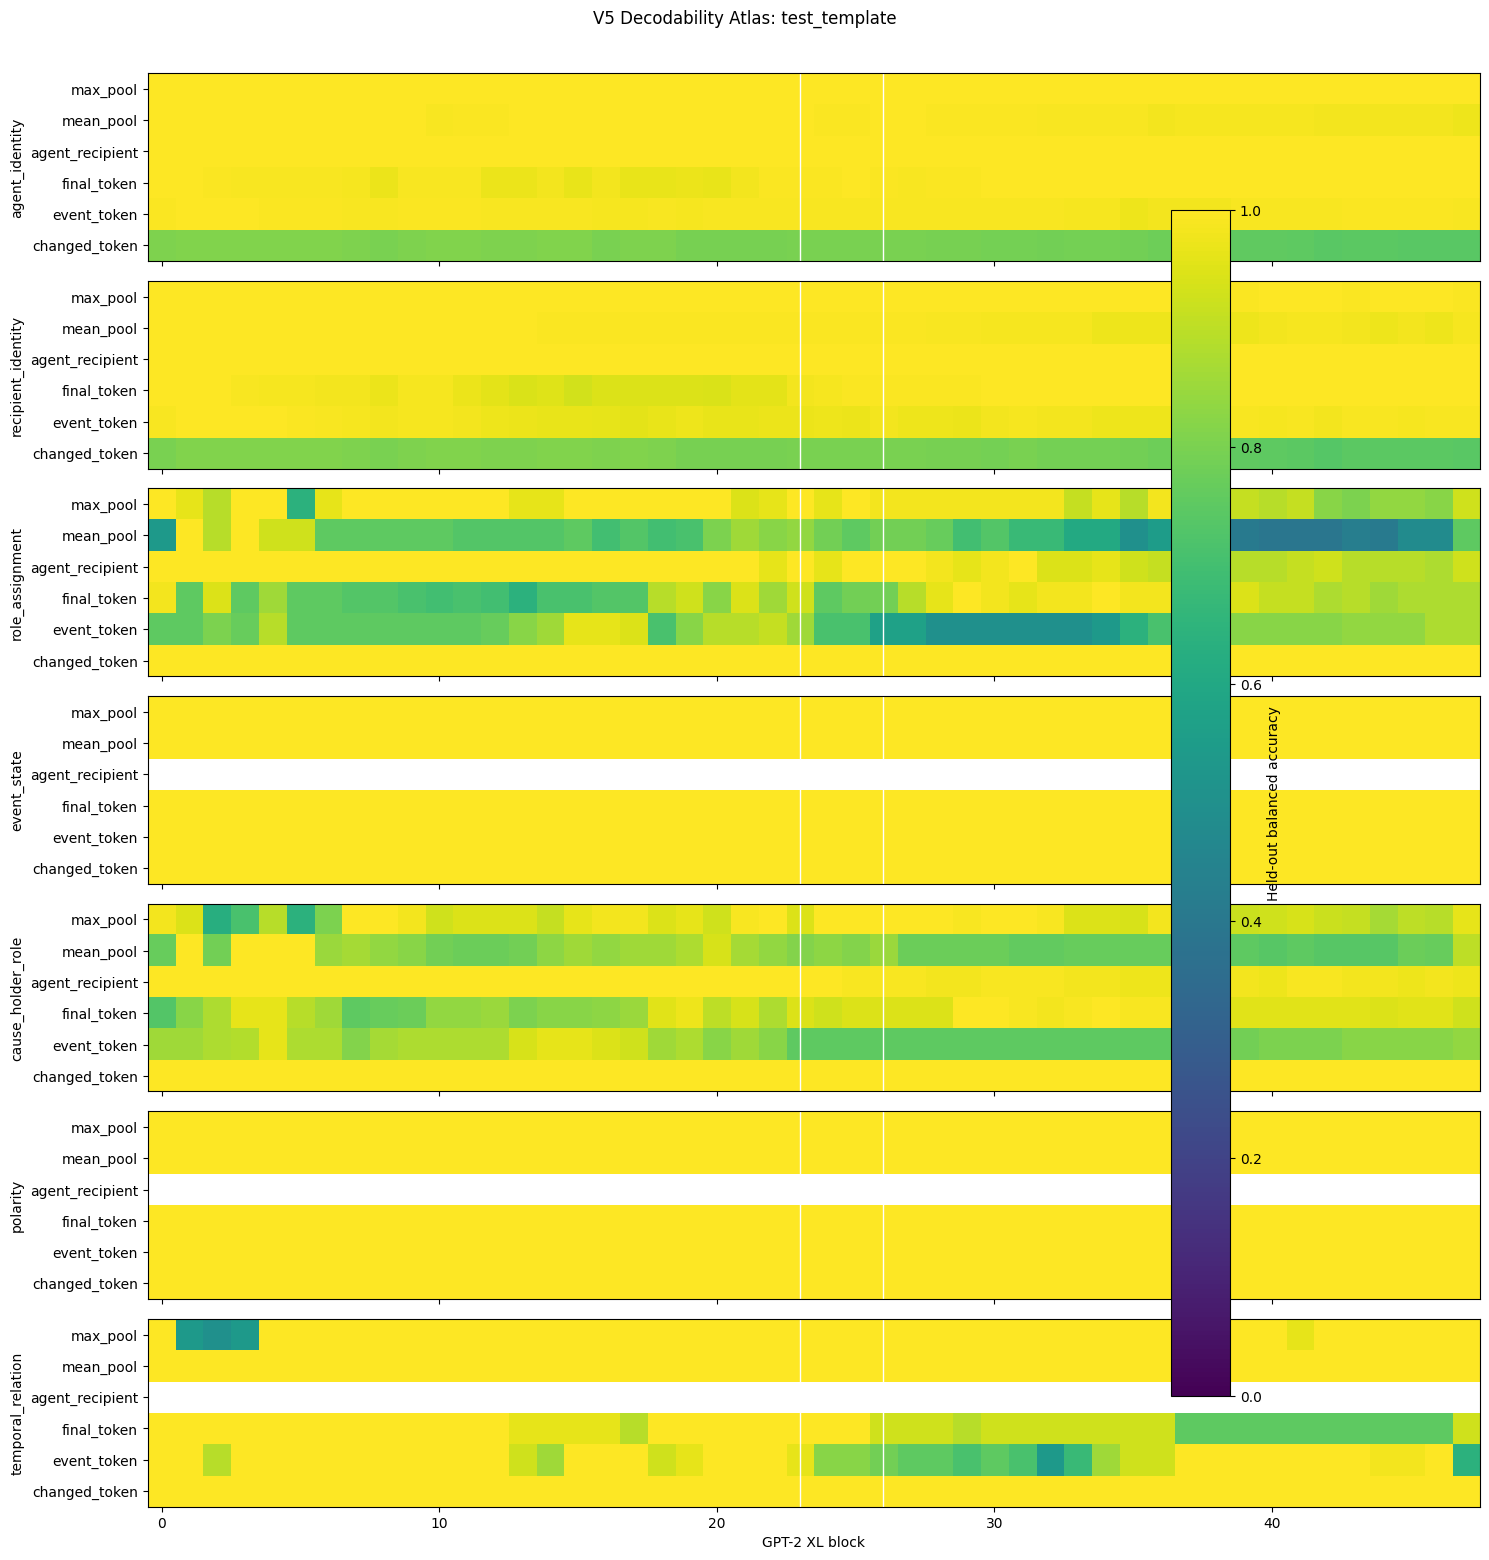

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/atlas_test_template.png


/tmp/ipykernel_8718/743392799.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


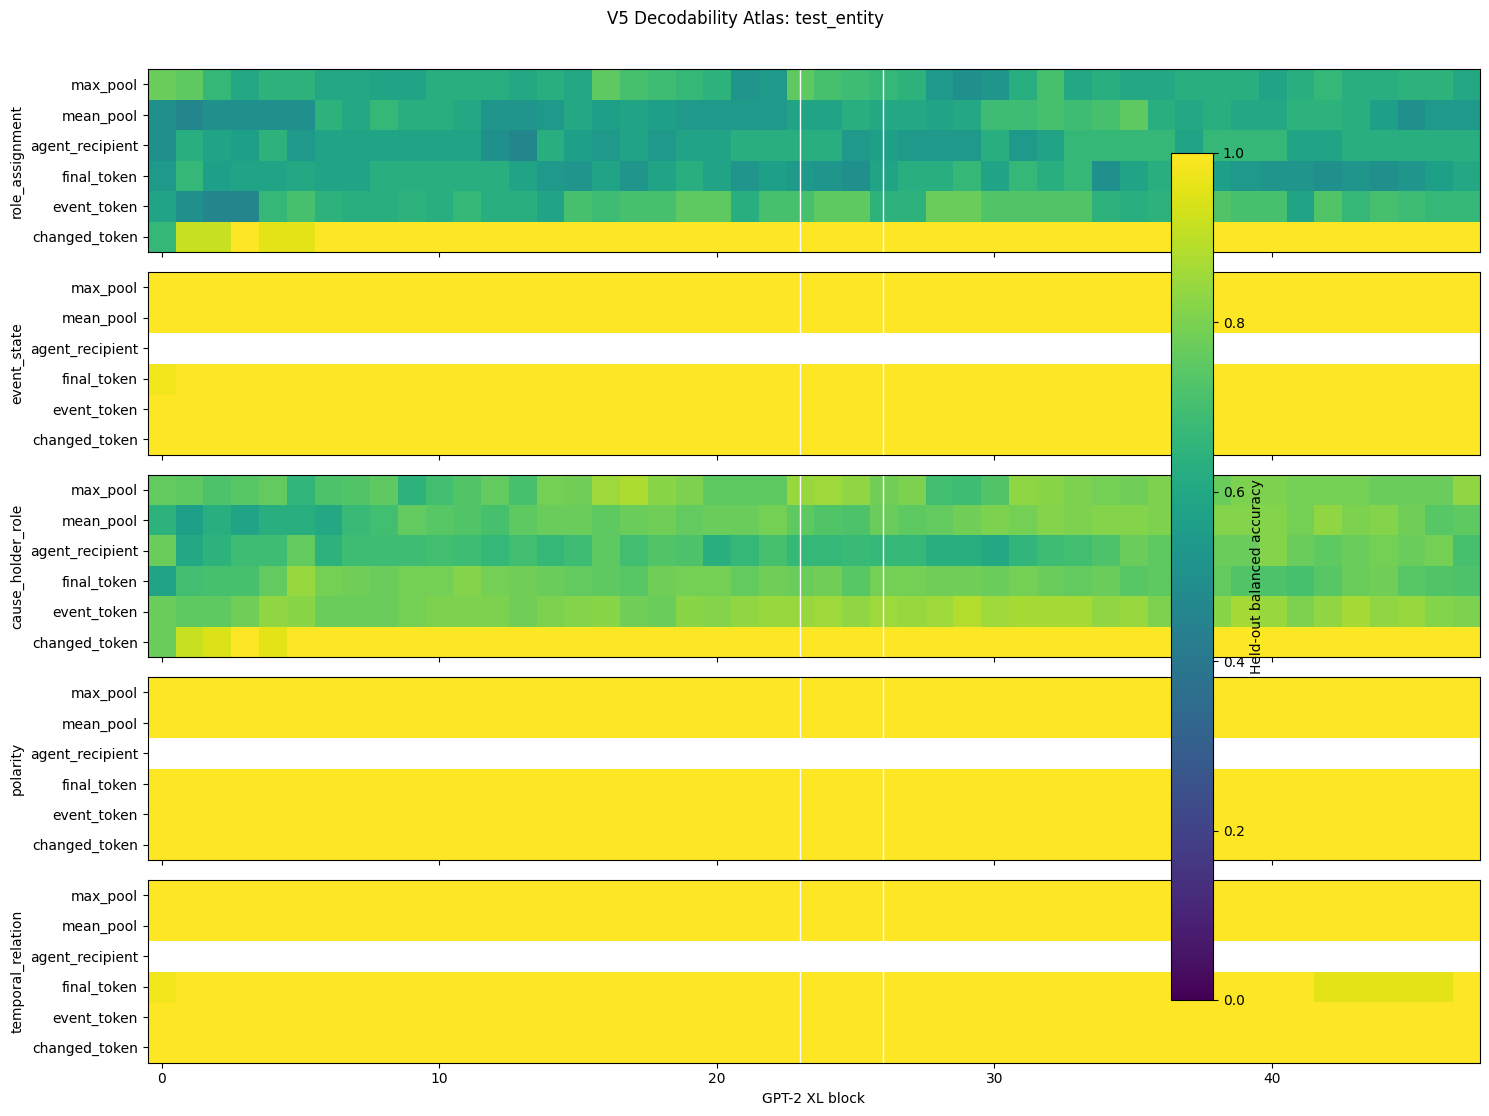

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/atlas_test_entity.png


/tmp/ipykernel_8718/743392799.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


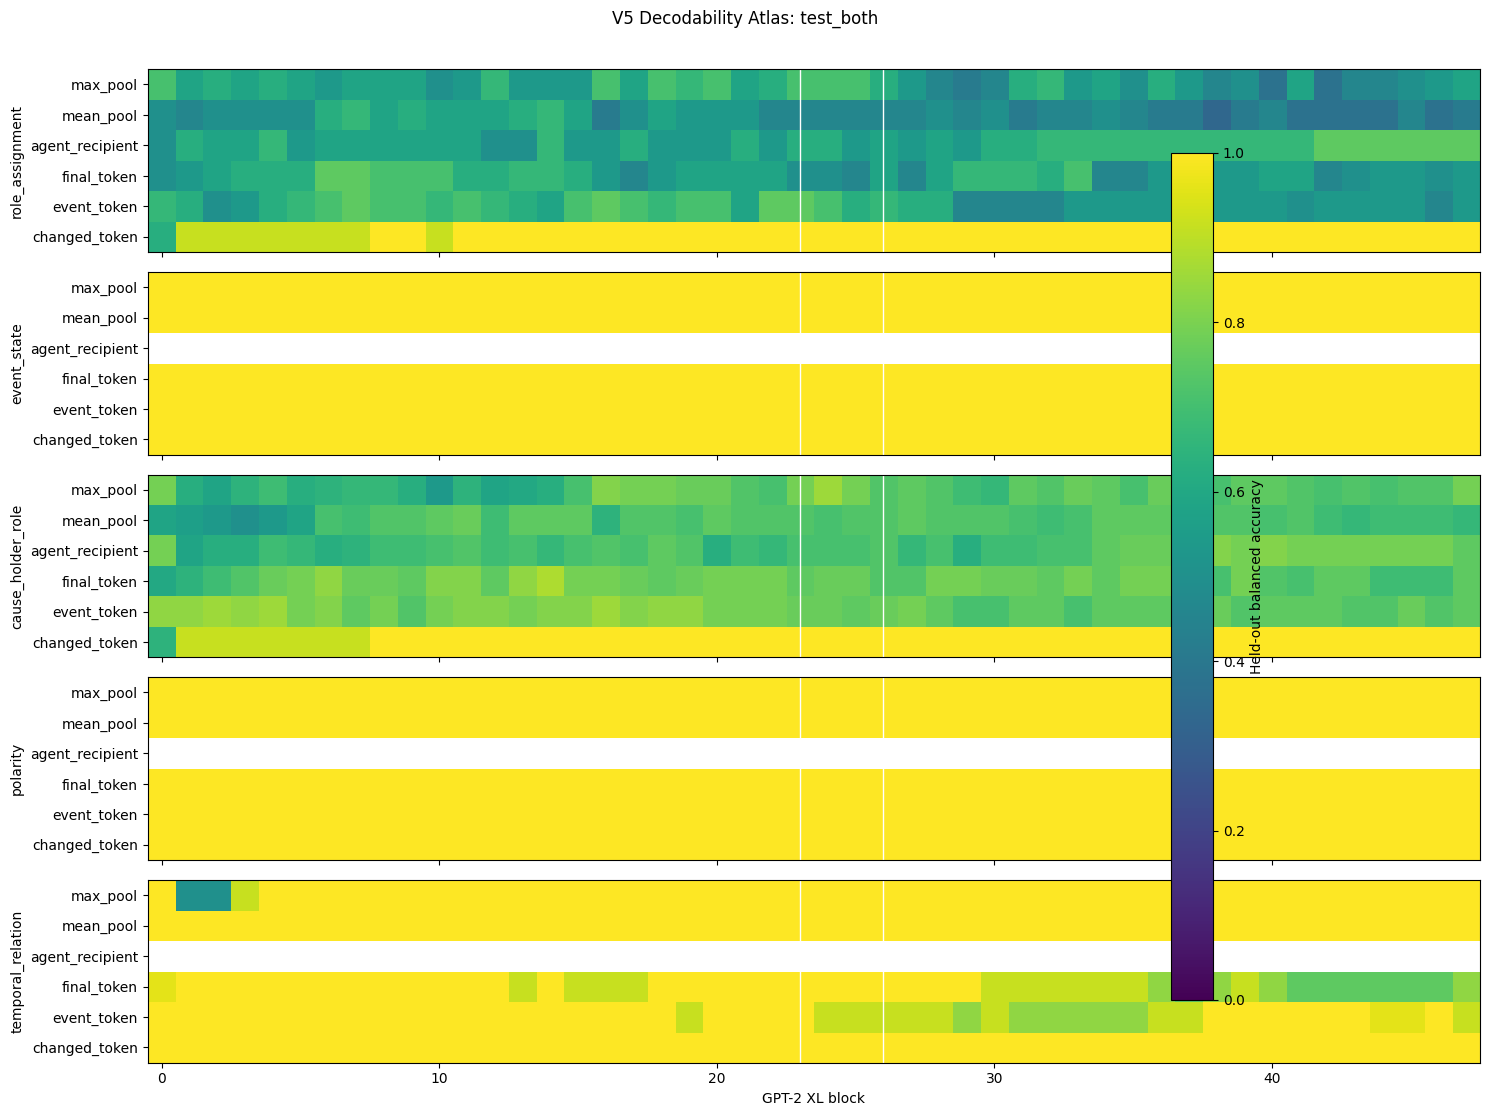

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/atlas_test_both.png
Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/decodability_summary.csv


,task,readout,test_split,peak_score,peak_layer
0,agent_identity,agent_recipient,test_template,1.000000,0.0
1,agent_identity,changed_token,test_template,0.809524,11.0
2,agent_identity,event_token,test_template,1.000000,1.0
3,agent_identity,final_token,test_template,1.000000,0.0
4,agent_identity,max_pool,test_template,1.000000,0.0
...,...,...,...,...,...
97,temporal_relation,max_pool,test_entity,1.000000,0.0
98,temporal_relation,max_pool,test_template,1.000000,0.0
99,temporal_relation,mean_pool,test_both,1.000000,0.0
100,temporal_relation,mean_pool,test_entity,1.000000,0.0


Looking for V4 geometry at:
/content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/heldout_layer_curves.csv
V4 numeric curves were not found at that path. V5 atlas figures and summaries were still saved normally.

V5 outputs:
 - atlas_test_both.png
 - atlas_test_entity.png
 - atlas_test_template.png
 - decodability_atlas.csv
 - decodability_summary.csv

Interpretation boundary: V5 measures decodability; V6 tests causal necessity.


In [ ]:
# =============================================================================
# V5.3: DECODABILITY ATLAS VISUALIZATION + SUMMARY ANALYSIS
#
# Visualizes held-out linear-probe accuracy across GPT-2 XL layers/readouts,
# exports peak decodability summaries, and compares decodability with V4
# geometry curves when available.
#
# All outputs are saved to:
#   OUTPUT_DIR = ARTIFACT_DIR / "v5_decodability"
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# 0. VERIFY ATLAS
# =============================================================================

print(f"Atlas rows: {len(atlas):,}")
print(f"Saving V5 outputs to: {OUTPUT_DIR}")

display(
    atlas.groupby("control")
    .size()
    .rename("n_results")
)


# =============================================================================
# 1. PLOT DECODABILITY HEATMAPS
# =============================================================================

for test_split in (
    "test_template",
    "test_entity",
    "test_both"
):

    subset = atlas.query(
        "test_split == @test_split and control == 'linear'"
    ).copy()

    if subset.empty:
        print(f"No linear results for {test_split}; skipping.")
        continue


    tasks = subset["task"].unique()

    fig, axes = plt.subplots(
        len(tasks),
        1,
        figsize=(15, 2.2 * len(tasks)),
        sharex=True
    )

    axes = np.atleast_1d(axes)


    for axis, task in zip(axes, tasks):

        matrix = (
            subset
            .query("task == @task")
            .pivot(
                index="readout",
                columns="layer",
                values="score"
            )
            .reindex(READOUTS)
        )


        image = axis.imshow(
            matrix,
            aspect="auto",
            origin="lower",
            vmin=0,
            vmax=1,
            cmap="viridis"
        )


        axis.set(
            yticks=range(len(READOUTS)),
            yticklabels=READOUTS,
            ylabel=task
        )


        # ---------------------------------------------------------
        # Optional hypothesized transition boundaries
        # ---------------------------------------------------------

        axis.axvline(
            23,
            color="white",
            linewidth=1
        )

        axis.axvline(
            26,
            color="white",
            linewidth=1
        )


    axes[-1].set_xlabel(
        "GPT-2 XL block"
    )


    fig.colorbar(
        image,
        ax=axes,
        label="Held-out balanced accuracy"
    )


    fig.suptitle(
        f"V5 Decodability Atlas: {test_split}",
        y=1.01
    )


    fig.tight_layout()


    output_path = (
        OUTPUT_DIR
        / f"atlas_{test_split}.png"
    )


    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()

    print(f"Saved: {output_path}")


# =============================================================================
# 2. PEAK DECODABILITY SUMMARY
# =============================================================================

linear = atlas.query(
    "control == 'linear'"
).copy()


def peak_result(frame):

    valid = frame.dropna(
        subset=["score"]
    )

    if valid.empty:

        return pd.Series({
            "peak_score": np.nan,
            "peak_layer": np.nan
        })


    best_idx = valid[
        "score"
    ].idxmax()


    return pd.Series({
        "peak_score": valid.loc[
            best_idx,
            "score"
        ],

        "peak_layer": valid.loc[
            best_idx,
            "layer"
        ]
    })


summary = (
    linear
    .groupby(
        [
            "task",
            "readout",
            "test_split"
        ],
        group_keys=False
    )
    .apply(
        peak_result,
        include_groups=False
    )
    .reset_index()
)


summary_path = (
    OUTPUT_DIR
    / "decodability_summary.csv"
)


summary.to_csv(
    summary_path,
    index=False
)


print(f"Saved: {summary_path}")

display(
    summary
)


# =============================================================================
# 3. COMPARE V5 DECODABILITY WITH V4 GEOMETRY
# =============================================================================

# Adjust ONLY this filename/path if your V4 geometry CSV is stored elsewhere.
#
# This assumes heldout_layer_curves.csv is directly inside:
#   SituationionArtifacts/
#
# If yours is in a subfolder, change the path here.

v4_path = (
    ARTIFACT_DIR
    / "heldout_layer_curves.csv"
)


print(
    f"Looking for V4 geometry at:\n{v4_path}"
)


if v4_path.exists():

    geometry = (
        pd.read_csv(
            v4_path
        )
        .rename(
            columns={
                "mean": "geometry"
            }
        )
    )


    # -------------------------------------------------------------
    # Basic schema check
    # -------------------------------------------------------------

    required_geometry_columns = {
        "readout",
        "layer",
        "geometry"
    }

    missing_geometry_columns = (
        required_geometry_columns
        - set(geometry.columns)
    )


    if missing_geometry_columns:

        print(
            "V4 geometry file was found, but these required "
            f"columns are missing: {sorted(missing_geometry_columns)}"
        )

    else:

        joined = linear.merge(
            geometry[
                [
                    "readout",
                    "layer",
                    "geometry"
                ]
            ],
            on=[
                "readout",
                "layer"
            ],
            how="inner"
        )


        print(
            f"Matched {len(joined):,} V5/V4 rows "
            f"for geometry comparison."
        )


        def safe_correlation(frame):

            valid = frame[
                [
                    "geometry",
                    "score"
                ]
            ].dropna()

            if len(valid) < 2:
                return np.nan


            return valid[
                "geometry"
            ].corr(
                valid["score"]
            )


        correlations = (
            joined
            .groupby(
                [
                    "task",
                    "readout",
                    "test_split"
                ],
                group_keys=False
            )
            .apply(
                safe_correlation,
                include_groups=False
            )
            .rename(
                "pearson_r"
            )
            .reset_index()
        )


        correlations_path = (
            OUTPUT_DIR
            / "geometry_decodability_correlations.csv"
        )


        correlations.to_csv(
            correlations_path,
            index=False
        )


        print(
            f"Saved: {correlations_path}"
        )


        display(
            correlations.round(3)
        )


else:

    print(
        "V4 numeric curves were not found at that path. "
        "V5 atlas figures and summaries were still saved normally."
    )


# =============================================================================
# 4. FINAL OUTPUT SUMMARY
# =============================================================================

print("\nV5 outputs:")

for path in sorted(
    OUTPUT_DIR.glob("*")
):
    print(" -", path.name)


# =============================================================================
# INTERPRETATION BOUNDARY
# =============================================================================

print(
    "\nInterpretation boundary: "
    "V5 measures decodability; "
    "V6 tests causal necessity."
)

-------
-------
-------

In [ ]:
# =============================================================================
# V5.4: CONTROL-ADJUSTED DECODABILITY + GENERALIZATION DIAGNOSTICS
#
# Purpose:
#   Go beyond raw balanced accuracy and ask:
#
#   1. Does the original hidden-state probe outperform lexical shortcuts?
#   2. Does it outperform a generic random projection of the same representation?
#   3. Does decodability generalize to held-out entities/templates?
#   4. Does information emerge, disappear, or move across readout locations?
#   5. Where does decodability change most sharply across transformer depth?
#
# Outputs:
#   - control_adjusted_lexical_*.png
#   - control_adjusted_random_projection_*.png
#   - conservative_advantage_*.png
#   - layer_trajectories_*.png
#   - split_robustness_*.png
#   - generalization_gap_*.png
#   - early_late_gain.png
#   - best_readout_by_layer_*.png
#   - first_emergence_layer.png
#   - layer_auc.png
#   - decodability_derivative_*.png
#   - diagnostic_summary.csv
#
# Assumes:
#   atlas columns =
#       task, readout, layer, test_split, control, score
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# 0. OUTPUT DIRECTORY + BASIC DATA
# =============================================================================

DIAGNOSTIC_DIR = (
    OUTPUT_DIR
    / "diagnostics"
)

DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


linear = (
    atlas
    .query("control == 'linear'")
    .copy()
)


random_projection = (
    atlas
    .query("control == 'random_projection'")
    .copy()
)


lexical = (
    atlas
    .query("control == 'lexical'")
    .copy()
)


shuffled = (
    atlas
    .query("control == 'shuffled_labels'")
    .copy()
)


majority = (
    atlas
    .query("control == 'majority'")
    .copy()
)


print(
    f"Saving diagnostic figures to:\n"
    f"{DIAGNOSTIC_DIR}"
)


# =============================================================================
# 1. BUILD CONTROL-ADJUSTED DATA
# =============================================================================
#
# Lexical and majority controls do not vary by layer/readout.
# Random projection and shuffled-label controls do.
#
# We therefore merge:
#
#   linear(task, readout, layer, split)
#
# with:
#
#   lexical(task, split)
#   majority(task, split)
#   random_projection(task, readout, layer, split)
#   shuffled_labels(task, readout, layer, split)
#
# =============================================================================

lexical_small = (
    lexical[
        [
            "task",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "lexical_score"
        }
    )
)


majority_small = (
    majority[
        [
            "task",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "majority_score"
        }
    )
)


rp_small = (
    random_projection[
        [
            "task",
            "readout",
            "layer",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "random_projection_score"
        }
    )
)


shuffled_small = (
    shuffled[
        [
            "task",
            "readout",
            "layer",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "shuffled_score"
        }
    )
)


diagnostic = (
    linear
    .rename(
        columns={
            "score": "linear_score"
        }
    )
    .merge(
        lexical_small,
        on=[
            "task",
            "test_split"
        ],
        how="left"
    )
    .merge(
        majority_small,
        on=[
            "task",
            "test_split"
        ],
        how="left"
    )
    .merge(
        rp_small,
        on=[
            "task",
            "readout",
            "layer",
            "test_split"
        ],
        how="left"
    )
    .merge(
        shuffled_small,
        on=[
            "task",
            "readout",
            "layer",
            "test_split"
        ],
        how="left"
    )
)


diagnostic[
    "advantage_over_lexical"
] = (
    diagnostic["linear_score"]
    - diagnostic["lexical_score"]
)


diagnostic[
    "advantage_over_random_projection"
] = (
    diagnostic["linear_score"]
    - diagnostic["random_projection_score"]
)


diagnostic[
    "advantage_over_shuffled"
] = (
    diagnostic["linear_score"]
    - diagnostic["shuffled_score"]
)


diagnostic[
    "advantage_over_majority"
] = (
    diagnostic["linear_score"]
    - diagnostic["majority_score"]
)


# Conservative comparison:
# hidden-state probe must beat both lexical TF-IDF and random projection.

diagnostic[
    "strongest_nonchance_control"
] = (
    diagnostic[
        [
            "lexical_score",
            "random_projection_score"
        ]
    ]
    .max(
        axis=1
    )
)


diagnostic[
    "conservative_advantage"
] = (
    diagnostic["linear_score"]
    - diagnostic[
        "strongest_nonchance_control"
    ]
)


diagnostic_path = (
    DIAGNOSTIC_DIR
    / "control_adjusted_scores.csv"
)


diagnostic.to_csv(
    diagnostic_path,
    index=False
)


print(
    f"Saved: {diagnostic_path}"
)


# =============================================================================
# HELPER: TASK × READOUT HEATMAP
# =============================================================================

def plot_metric_heatmaps(
    frame,
    metric,
    filename_prefix,
    title_prefix,
    vmin=None,
    vmax=None,
    cmap="viridis"
):

    for test_split in (
        "test_template",
        "test_entity",
        "test_both"
    ):

        subset = frame.query(
            "test_split == @test_split"
        ).copy()


        if subset.empty:
            continue


        tasks = subset[
            "task"
        ].unique()


        fig, axes = plt.subplots(
            len(tasks),
            1,
            figsize=(
                15,
                2.2 * len(tasks)
            ),
            sharex=True
        )


        axes = np.atleast_1d(
            axes
        )


        image = None


        for axis, task in zip(
            axes,
            tasks
        ):

            matrix = (
                subset
                .query(
                    "task == @task"
                )
                .pivot(
                    index="readout",
                    columns="layer",
                    values=metric
                )
                .reindex(
                    READOUTS
                )
            )


            image = axis.imshow(
                matrix,
                aspect="auto",
                origin="lower",
                vmin=vmin,
                vmax=vmax,
                cmap=cmap
            )


            axis.set(
                yticks=range(
                    len(READOUTS)
                ),
                yticklabels=READOUTS,
                ylabel=task
            )


            axis.axvline(
                23,
                linewidth=1
            )


            axis.axvline(
                26,
                linewidth=1
            )


        axes[-1].set_xlabel(
            "GPT-2 XL block"
        )


        fig.colorbar(
            image,
            ax=axes,
            label=metric.replace(
                "_",
                " "
            )
        )


        fig.suptitle(
            f"{title_prefix}: "
            f"{test_split}",
            y=1.01
        )


        output_path = (
            DIAGNOSTIC_DIR
            / (
                f"{filename_prefix}_"
                f"{test_split}.png"
            )
        )


        fig.savefig(
            output_path,
            dpi=180,
            bbox_inches="tight"
        )


        plt.show()

        print(
            f"Saved: {output_path}"
        )


# =============================================================================
# 2. CONTROL-ADJUSTED HEATMAPS
# =============================================================================
#
# Positive values mean the original hidden-state probe beats the control.
# Zero means no advantage.
# Negative means the control actually performs better.
#
# =============================================================================

plot_metric_heatmaps(
    diagnostic,
    metric="advantage_over_lexical",
    filename_prefix="control_adjusted_lexical",
    title_prefix=(
        "Linear hidden-state advantage "
        "over TF-IDF"
    ),
    vmin=-0.5,
    vmax=0.5,
    cmap="coolwarm"
)


plot_metric_heatmaps(
    diagnostic,
    metric="advantage_over_random_projection",
    filename_prefix="control_adjusted_random_projection",
    title_prefix=(
        "Linear hidden-state advantage "
        "over random projection"
    ),
    vmin=-0.5,
    vmax=0.5,
    cmap="coolwarm"
)


plot_metric_heatmaps(
    diagnostic,
    metric="conservative_advantage",
    filename_prefix="conservative_advantage",
    title_prefix=(
        "Linear advantage over strongest "
        "lexical / projection control"
    ),
    vmin=-0.5,
    vmax=0.5,
    cmap="coolwarm"
)


# =============================================================================
# 3. RAW LAYER TRAJECTORIES
# =============================================================================
#
# One figure per task and test split.
# Each readout gets its own trajectory across GPT-2 XL blocks.
#
# =============================================================================

for test_split in (
    "test_template",
    "test_entity",
    "test_both"
):

    for task in linear[
        "task"
    ].unique():

        subset = (
            linear
            .query(
                "task == @task "
                "and test_split == @test_split"
            )
        )


        if subset.empty:
            continue


        fig, ax = plt.subplots(
            figsize=(12, 6)
        )


        for readout in READOUTS:

            curve = (
                subset
                .query(
                    "readout == @readout"
                )
                .sort_values(
                    "layer"
                )
            )


            if curve.empty:
                continue


            ax.plot(
                curve["layer"],
                curve["score"],
                marker="o",
                markersize=2,
                linewidth=1.5,
                label=readout
            )


        ax.axvline(
            23,
            linestyle="--",
            alpha=0.6
        )


        ax.axvline(
            26,
            linestyle="--",
            alpha=0.6
        )


        ax.set(
            xlabel="GPT-2 XL block",
            ylabel="Held-out balanced accuracy",
            ylim=(0, 1.05),
            title=(
                f"Layer trajectories: "
                f"{task} | {test_split}"
            )
        )


        ax.legend(
            bbox_to_anchor=(
                1.02,
                1
            ),
            loc="upper left"
        )


        output_path = (
            DIAGNOSTIC_DIR
            / (
                f"layer_trajectories_"
                f"{task}_"
                f"{test_split}.png"
            )
        )


        fig.savefig(
            output_path,
            dpi=180,
            bbox_inches="tight"
        )


        plt.show()


# =============================================================================
# 4. SPLIT ROBUSTNESS PLOTS
# =============================================================================
#
# For each task/readout, overlay:
#   test_template
#   test_entity
#   test_both
#
# This directly reveals whether apparent decodability survives harder
# generalization conditions.
#
# =============================================================================

for task in linear[
    "task"
].unique():

    for readout in READOUTS:

        subset = (
            linear
            .query(
                "task == @task "
                "and readout == @readout"
            )
        )


        if subset.empty:
            continue


        fig, ax = plt.subplots(
            figsize=(11, 5)
        )


        found_split = False


        for test_split in (
            "test_template",
            "test_entity",
            "test_both"
        ):

            curve = (
                subset
                .query(
                    "test_split == @test_split"
                )
                .sort_values(
                    "layer"
                )
            )


            if curve.empty:
                continue


            found_split = True


            ax.plot(
                curve["layer"],
                curve["score"],
                marker="o",
                markersize=2,
                label=test_split
            )


        if not found_split:
            plt.close(fig)
            continue


        ax.set(
            xlabel="GPT-2 XL block",
            ylabel="Balanced accuracy",
            ylim=(0, 1.05),
            title=(
                f"Generalization robustness: "
                f"{task} | {readout}"
            )
        )


        ax.legend()


        output_path = (
            DIAGNOSTIC_DIR
            / (
                f"split_robustness_"
                f"{task}_"
                f"{readout}.png"
            )
        )


        fig.savefig(
            output_path,
            dpi=180,
            bbox_inches="tight"
        )


        plt.show()


# =============================================================================
# 5. GENERALIZATION GAP CURVES
# =============================================================================
#
# Gap definitions:
#
#   template_minus_entity =
#       test_template - test_entity
#
#   template_minus_both =
#       test_template - test_both
#
# Larger positive values mean the easier template split overestimates
# generalization relative to entity/joint holdout.
#
# =============================================================================

split_wide = (
    linear
    .pivot_table(
        index=[
            "task",
            "readout",
            "layer"
        ],
        columns="test_split",
        values="score"
    )
    .reset_index()
)


if {
    "test_template",
    "test_entity"
}.issubset(
    split_wide.columns
):

    split_wide[
        "template_minus_entity"
    ] = (
        split_wide["test_template"]
        - split_wide["test_entity"]
    )


if {
    "test_template",
    "test_both"
}.issubset(
    split_wide.columns
):

    split_wide[
        "template_minus_both"
    ] = (
        split_wide["test_template"]
        - split_wide["test_both"]
    )


for metric in (
    "template_minus_entity",
    "template_minus_both"
):

    if metric not in split_wide:
        continue


    plot_metric_heatmaps(
        split_wide.assign(
            test_split="generalization_gap"
        ),
        metric=metric,
        filename_prefix=metric,
        title_prefix=metric.replace(
            "_",
            " "
        ),
        vmin=-0.5,
        vmax=0.5,
        cmap="coolwarm"
    )


# =============================================================================
# 6. EARLY-TO-LATE GAIN
# =============================================================================
#
# score(layer 47) - score(layer 0)
#
# Positive:
#   decodability is greater at the final transformer block.
#
# Negative:
#   decodability was stronger in the input/early representation.
#
# =============================================================================

early = (
    linear
    .query(
        "layer == 0"
    )[
        [
            "task",
            "readout",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "layer_0_score"
        }
    )
)


last_layer = max(
    linear["layer"]
)


late = (
    linear
    .query(
        "layer == @last_layer"
    )[
        [
            "task",
            "readout",
            "test_split",
            "score"
        ]
    ]
    .rename(
        columns={
            "score": "last_layer_score"
        }
    )
)


early_late = (
    early
    .merge(
        late,
        on=[
            "task",
            "readout",
            "test_split"
        ],
        how="inner"
    )
)


early_late[
    "late_minus_early"
] = (
    early_late["last_layer_score"]
    - early_late["layer_0_score"]
)


for test_split in early_late[
    "test_split"
].unique():

    subset = early_late.query(
        "test_split == @test_split"
    )


    matrix = (
        subset
        .pivot(
            index="task",
            columns="readout",
            values="late_minus_early"
        )
        .reindex(
            columns=READOUTS
        )
    )


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    image = ax.imshow(
        matrix,
        aspect="auto",
        vmin=-0.5,
        vmax=0.5,
        cmap="coolwarm"
    )


    ax.set(
        xticks=range(
            len(matrix.columns)
        ),
        xticklabels=matrix.columns,
        yticks=range(
            len(matrix.index)
        ),
        yticklabels=matrix.index,
        xlabel="Readout",
        ylabel="Task",
        title=(
            "Late minus early decodability: "
            f"{test_split}"
        )
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )


    fig.colorbar(
        image,
        ax=ax,
        label=(
            f"Layer {last_layer} "
            "- layer 0 accuracy"
        )
    )


    output_path = (
        DIAGNOSTIC_DIR
        / (
            f"early_late_gain_"
            f"{test_split}.png"
        )
    )


    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()


# =============================================================================
# 7. BEST READOUT BY LAYER
# =============================================================================
#
# For each task and layer:
#   Which readout has the highest linear-probe score?
#
# This is useful for testing whether information appears to move between
# token positions / pooling strategies across transformer depth.
#
# =============================================================================

readout_to_id = {
    readout: i
    for i, readout in enumerate(
        READOUTS
    )
}


for test_split in (
    "test_template",
    "test_entity",
    "test_both"
):

    subset = linear.query(
        "test_split == @test_split"
    )


    if subset.empty:
        continue


    best_rows = (
        subset
        .dropna(
            subset=["score"]
        )
        .sort_values(
            "score",
            ascending=False
        )
        .drop_duplicates(
            subset=[
                "task",
                "layer"
            ]
        )
    )


    best_rows[
        "readout_id"
    ] = (
        best_rows[
            "readout"
        ]
        .map(
            readout_to_id
        )
    )


    matrix = (
        best_rows
        .pivot(
            index="task",
            columns="layer",
            values="readout_id"
        )
    )


    fig, ax = plt.subplots(
        figsize=(15, 5)
    )


    image = ax.imshow(
        matrix,
        aspect="auto",
        origin="lower",
        cmap="tab20",
        vmin=-0.5,
        vmax=len(READOUTS) - 0.5
    )


    ax.set(
        yticks=range(
            len(matrix.index)
        ),
        yticklabels=matrix.index,
        xlabel="GPT-2 XL block",
        ylabel="Task",
        title=(
            "Best-performing readout by layer: "
            f"{test_split}"
        )
    )


    colorbar = fig.colorbar(
        image,
        ax=ax,
        ticks=range(
            len(READOUTS)
        )
    )


    colorbar.ax.set_yticklabels(
        READOUTS
    )


    output_path = (
        DIAGNOSTIC_DIR
        / (
            f"best_readout_by_layer_"
            f"{test_split}.png"
        )
    )


    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()


# =============================================================================
# 8. FIRST EMERGENCE ABOVE CONTROL
# =============================================================================
#
# We define "emergence" conservatively as the first layer where:
#
#   linear_score - max(lexical, random_projection) >= 0.10
#
# Change EMERGENCE_MARGIN if you want a different threshold.
#
# IMPORTANT:
#   This is a descriptive threshold, not a statistical significance test.
#
# =============================================================================

EMERGENCE_MARGIN = 0.10


def first_emergence(
    frame
):

    valid = (
        frame
        .dropna(
            subset=[
                "conservative_advantage"
            ]
        )
        .sort_values(
            "layer"
        )
    )


    emerging = valid[
        valid[
            "conservative_advantage"
        ] >= EMERGENCE_MARGIN
    ]


    if emerging.empty:
        return np.nan


    return emerging[
        "layer"
    ].iloc[0]


emergence = (
    diagnostic
    .groupby(
        [
            "task",
            "readout",
            "test_split"
        ]
    )
    .apply(
        first_emergence,
        include_groups=False
    )
    .rename(
        "first_emergence_layer"
    )
    .reset_index()
)


for test_split in emergence[
    "test_split"
].unique():

    subset = emergence.query(
        "test_split == @test_split"
    )


    matrix = (
        subset
        .pivot(
            index="task",
            columns="readout",
            values="first_emergence_layer"
        )
        .reindex(
            columns=READOUTS
        )
    )


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap="viridis",
        vmin=0,
        vmax=last_layer
    )


    ax.set(
        xticks=range(
            len(matrix.columns)
        ),
        xticklabels=matrix.columns,
        yticks=range(
            len(matrix.index)
        ),
        yticklabels=matrix.index,
        title=(
            "First layer with ≥ "
            f"{EMERGENCE_MARGIN:.2f} "
            "advantage over lexical/RP controls: "
            f"{test_split}"
        )
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )


    fig.colorbar(
        image,
        ax=ax,
        label="First emergence layer"
    )


    output_path = (
        DIAGNOSTIC_DIR
        / (
            f"first_emergence_layer_"
            f"{test_split}.png"
        )
    )


    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()


# =============================================================================
# 9. AREA UNDER THE LAYER CURVE
# =============================================================================
#
# AUC gives a stable summary of decodability across the entire network,
# rather than selecting one potentially lucky "peak" layer.
#
# We normalize by the layer range so values remain on roughly the 0–1
# accuracy scale.
#
# =============================================================================

def normalized_layer_auc(
    frame
):

    valid = (
        frame
        .dropna(
            subset=["linear_score"]
        )
        .sort_values(
            "layer"
        )
    )


    if len(valid) < 2:
        return np.nan


    x = valid[
        "layer"
    ].to_numpy()


    y = valid[
        "linear_score"
    ].to_numpy()


    width = (
        x.max()
        - x.min()
    )


    if width == 0:
        return np.nan


    return (
        np.trapz(
            y,
            x
        )
        / width
    )


auc_summary = (
    diagnostic
    .groupby(
        [
            "task",
            "readout",
            "test_split"
        ]
    )
    .apply(
        normalized_layer_auc,
        include_groups=False
    )
    .rename(
        "layer_auc"
    )
    .reset_index()
)


for test_split in auc_summary[
    "test_split"
].unique():

    subset = auc_summary.query(
        "test_split == @test_split"
    )


    matrix = (
        subset
        .pivot(
            index="task",
            columns="readout",
            values="layer_auc"
        )
        .reindex(
            columns=READOUTS
        )
    )


    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    image = ax.imshow(
        matrix,
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="viridis"
    )


    ax.set(
        xticks=range(
            len(matrix.columns)
        ),
        xticklabels=matrix.columns,
        yticks=range(
            len(matrix.index)
        ),
        yticklabels=matrix.index,
        title=(
            "Normalized decodability AUC: "
            f"{test_split}"
        )
    )


    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right"
    )


    fig.colorbar(
        image,
        ax=ax,
        label="Mean layer-wise decodability"
    )


    output_path = (
        DIAGNOSTIC_DIR
        / (
            f"layer_auc_"
            f"{test_split}.png"
        )
    )


    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )


    plt.show()


# =============================================================================
# 10. LAYER-TO-LAYER DECODABILITY CHANGE
# =============================================================================
#
# This approximates a first derivative across transformer depth:
#
#   delta_l = score_l - score_(l-1)
#
# Positive:
#   information becomes more linearly accessible.
#
# Negative:
#   information becomes less linearly accessible.
#
# Large absolute values identify representation-transition regions.
#
# =============================================================================

derivative = (
    linear
    .sort_values(
        [
            "task",
            "readout",
            "test_split",
            "layer"
        ]
    )
    .copy()
)


derivative[
    "delta_score"
] = (
    derivative
    .groupby(
        [
            "task",
            "readout",
            "test_split"
        ]
    )[
        "score"
    ]
    .diff()
)


plot_metric_heatmaps(
    derivative,
    metric="delta_score",
    filename_prefix="decodability_derivative",
    title_prefix=(
        "Layer-to-layer change in "
        "linear decodability"
    ),
    vmin=-0.25,
    vmax=0.25,
    cmap="coolwarm"
)


# =============================================================================
# 11. CONTROL-ADJUSTED TRAJECTORIES
# =============================================================================
#
# These may be the most important line plots:
#
#   conservative_advantage =
#       linear -
#       max(lexical, random_projection)
#
# =============================================================================

for test_split in (
    "test_template",
    "test_entity",
    "test_both"
):

    for task in diagnostic[
        "task"
    ].unique():

        subset = (
            diagnostic
            .query(
                "task == @task "
                "and test_split == @test_split"
            )
        )


        if subset.empty:
            continue


        fig, ax = plt.subplots(
            figsize=(12, 6)
        )


        for readout in READOUTS:

            curve = (
                subset
                .query(
                    "readout == @readout"
                )
                .sort_values(
                    "layer"
                )
            )


            if curve.empty:
                continue


            ax.plot(
                curve["layer"],
                curve[
                    "conservative_advantage"
                ],
                marker="o",
                markersize=2,
                linewidth=1.5,
                label=readout
            )


        ax.axhline(
            0,
            linewidth=1
        )


        ax.axvline(
            23,
            linestyle="--",
            alpha=0.6
        )


        ax.axvline(
            26,
            linestyle="--",
            alpha=0.6
        )


        ax.set(
            xlabel="GPT-2 XL block",
            ylabel=(
                "Linear - strongest "
                "lexical/RP control"
            ),
            ylim=(-0.6, 0.6),
            title=(
                "Control-adjusted trajectory: "
                f"{task} | {test_split}"
            )
        )


        ax.legend(
            bbox_to_anchor=(
                1.02,
                1
            ),
            loc="upper left"
        )


        output_path = (
            DIAGNOSTIC_DIR
            / (
                f"control_adjusted_trajectory_"
                f"{task}_"
                f"{test_split}.png"
            )
        )


        fig.savefig(
            output_path,
            dpi=180,
            bbox_inches="tight"
        )


        plt.show()


# =============================================================================
# 12. CREATE A MORE USEFUL NUMERIC SUMMARY
# =============================================================================
#
# Adds:
#   - layer 0 score
#   - final layer score
#   - peak score
#   - first maximum layer
#   - normalized layer AUC
#   - early-to-late gain
#   - mean conservative advantage
#   - maximum conservative advantage
#   - first emergence layer
#
# =============================================================================

def trajectory_summary(
    frame
):

    valid = (
        frame
        .dropna(
            subset=[
                "linear_score"
            ]
        )
        .sort_values(
            "layer"
        )
    )


    if valid.empty:

        return pd.Series({
            "layer_0_score": np.nan,
            "final_layer_score": np.nan,
            "peak_score": np.nan,
            "first_peak_layer": np.nan,
            "layer_auc": np.nan,
            "late_minus_early": np.nan,
            "mean_control_adjusted": np.nan,
            "max_control_adjusted": np.nan,
            "first_emergence_layer": np.nan
        })


    layer0_row = valid[
        valid["layer"] == 0
    ]


    final_row = valid[
        valid["layer"] == valid[
            "layer"
        ].max()
    ]


    peak_score = valid[
        "linear_score"
    ].max()


    first_peak_layer = (
        valid[
            valid[
                "linear_score"
            ] == peak_score
        ][
            "layer"
        ]
        .min()
    )


    layer_0_score = (
        layer0_row[
            "linear_score"
        ].iloc[0]
        if not layer0_row.empty
        else np.nan
    )


    final_layer_score = (
        final_row[
            "linear_score"
        ].iloc[0]
        if not final_row.empty
        else np.nan
    )


    x = valid[
        "layer"
    ].to_numpy()


    y = valid[
        "linear_score"
    ].to_numpy()


    if len(valid) >= 2:

        layer_auc = (
            np.trapz(
                y,
                x
            )
            / (
                x.max()
                - x.min()
            )
        )

    else:

        layer_auc = np.nan


    advantage = valid[
        "conservative_advantage"
    ]


    emergence_rows = valid[
        advantage >= EMERGENCE_MARGIN
    ]


    return pd.Series({

        "layer_0_score":
            layer_0_score,

        "final_layer_score":
            final_layer_score,

        "peak_score":
            peak_score,

        "first_peak_layer":
            first_peak_layer,

        "layer_auc":
            layer_auc,

        "late_minus_early":
            final_layer_score
            - layer_0_score,

        "mean_control_adjusted":
            advantage.mean(),

        "max_control_adjusted":
            advantage.max(),

        "first_emergence_layer":
            (
                emergence_rows[
                    "layer"
                ].iloc[0]
                if not emergence_rows.empty
                else np.nan
            )
    })


diagnostic_summary = (
    diagnostic
    .groupby(
        [
            "task",
            "readout",
            "test_split"
        ],
        group_keys=False
    )
    .apply(
        trajectory_summary,
        include_groups=False
    )
    .reset_index()
)


diagnostic_summary_path = (
    DIAGNOSTIC_DIR
    / "diagnostic_summary.csv"
)


diagnostic_summary.to_csv(
    diagnostic_summary_path,
    index=False
)


print(
    f"Saved: "
    f"{diagnostic_summary_path}"
)


display(
    diagnostic_summary
    .sort_values(
        [
            "test_split",
            "max_control_adjusted"
        ],
        ascending=[
            True,
            False
        ]
    )
)


# =============================================================================
# 13. FINAL FILE LIST
# =============================================================================

print(
    "\nGenerated V5.4 diagnostic outputs:"
)


for path in sorted(
    DIAGNOSTIC_DIR.glob("*")
):

    print(
        " -",
        path.name
    )

-------
-------
-------

**Representation Constellation:**

Where in depth/readout space does GPT-2 XL contain information that beats the controls, where does it fail to generalize, and where are the sharp transitions?

Transition threshold: 0.1667


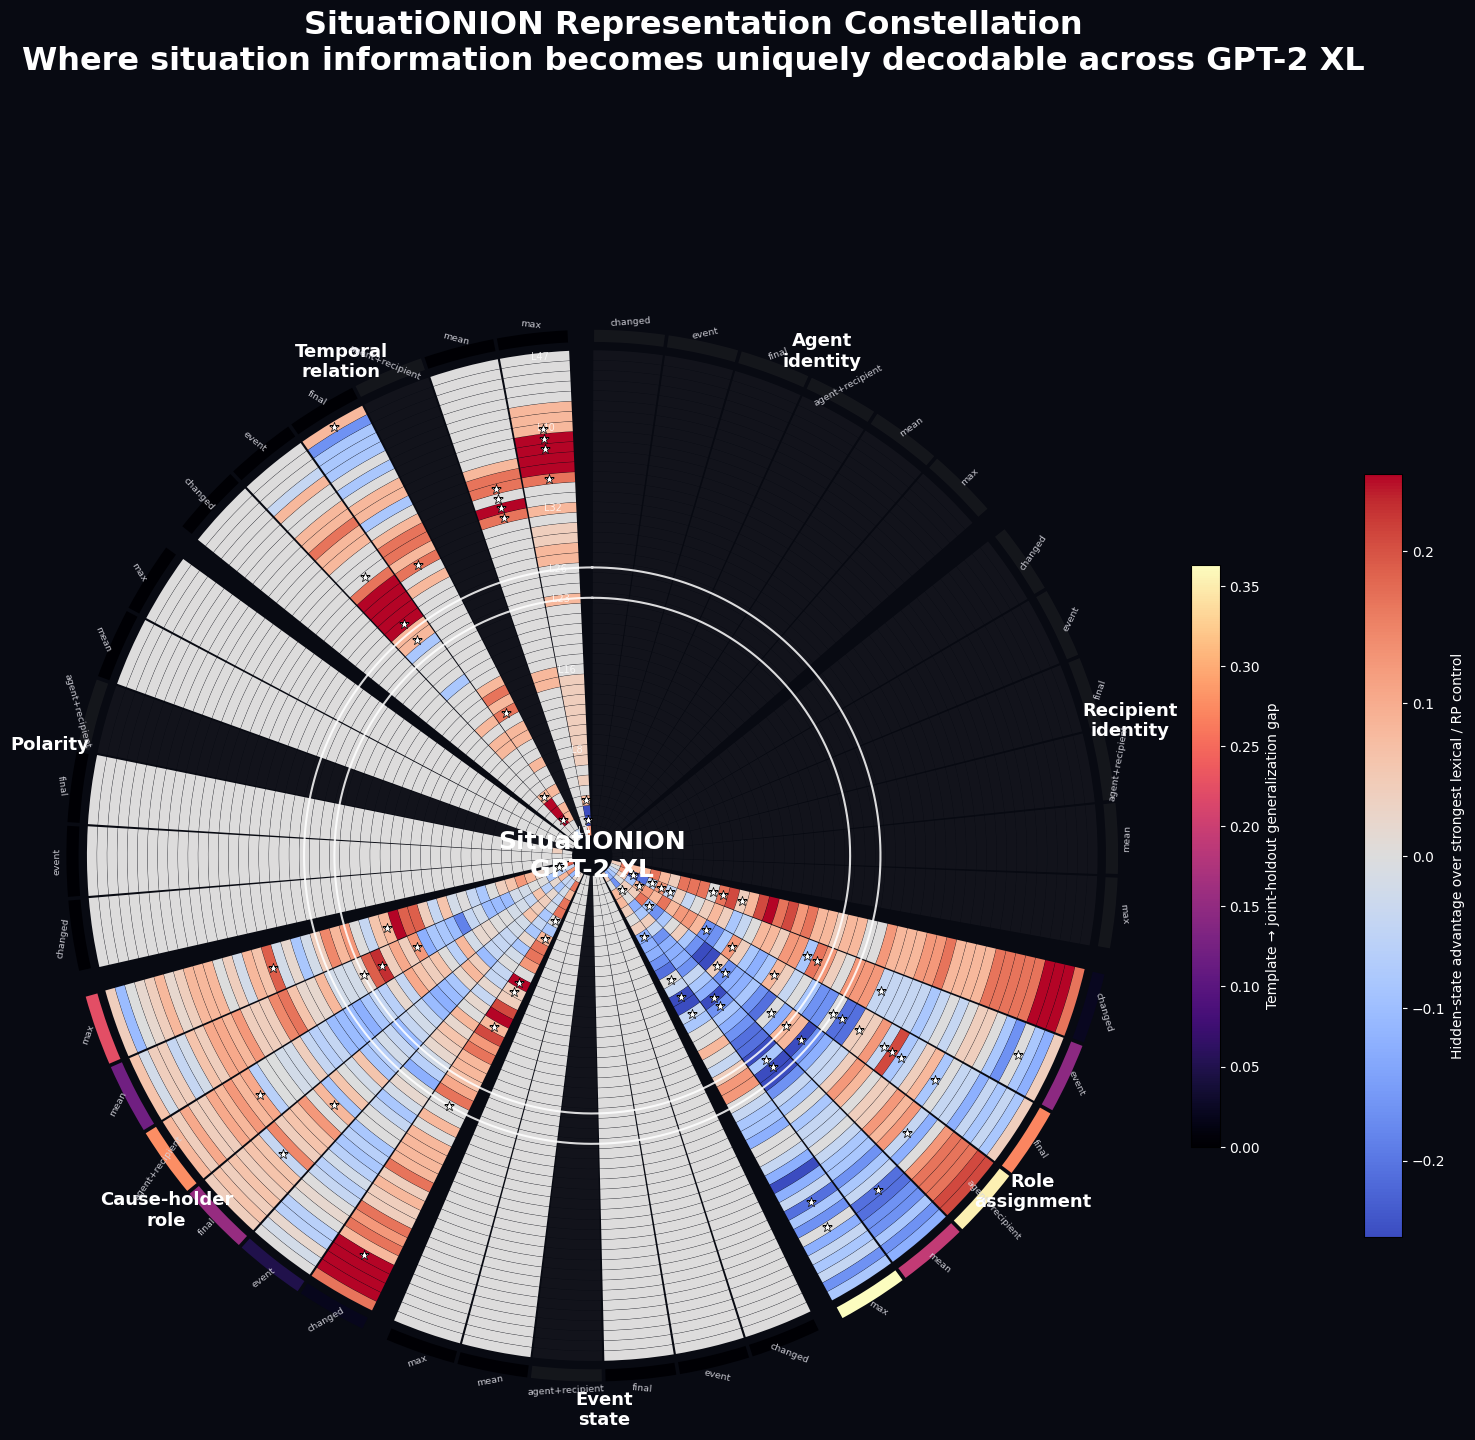

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/situationion_representation_constellation.png
Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/situationion_representation_constellation.pdf


In [ ]:
# =============================================================================
# V5.5 — SITUATIONION REPRESENTATION CONSTELLATION
# =============================================================================
#
# A radial "onion" map of GPT-2 XL situation representations.
#
# VISUAL ENCODING
# ----------------
# Radius:
#     GPT-2 XL layer / block
#     center = layer 0
#     outside = layer 47
#
# Angle:
#     task sector
#       └── subdivided into the six readout locations
#
# Cell color:
#     conservative_advantage
#
#         linear hidden-state probe
#              minus
#         max(TF-IDF lexical control,
#             random-projection control)
#
#     warm  -> hidden representation wins
#     neutral -> little unique advantage
#     cool  -> control performs better
#
# Outer ring:
#     generalization gap
#
#         test_template - test_both
#
#     larger gap = representation generalizes less robustly
#
# Star markers:
#     unusually large layer-to-layer changes in
#     control-adjusted decodability
#
# Output:
#     situationion_representation_constellation.png
#     situationion_representation_constellation.pdf
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable


# =============================================================================
# 0. LOAD V5.4 DATA IF NECESSARY
# =============================================================================

if "DIAGNOSTIC_DIR" not in globals():
    DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"

if "diagnostic" not in globals():

    diagnostic_path = (
        DIAGNOSTIC_DIR
        / "control_adjusted_scores.csv"
    )

    diagnostic = pd.read_csv(
        diagnostic_path
    )

    print(
        "Reloaded diagnostic data from:",
        diagnostic_path
    )


# =============================================================================
# 1. SETTINGS
# =============================================================================

PLOT_SPLIT = "test_both"

TASK_ORDER = [
    "agent_identity",
    "recipient_identity",
    "role_assignment",
    "event_state",
    "cause_holder_role",
    "polarity",
    "temporal_relation",
]

READOUT_ORDER = [
    "changed_token",
    "event_token",
    "final_token",
    "agent_recipient",
    "mean_pool",
    "max_pool",
]

# Slightly cleaner labels for the figure.
TASK_LABELS = {
    "agent_identity": "Agent\nidentity",
    "recipient_identity": "Recipient\nidentity",
    "role_assignment": "Role\nassignment",
    "event_state": "Event\nstate",
    "cause_holder_role": "Cause-holder\nrole",
    "polarity": "Polarity",
    "temporal_relation": "Temporal\nrelation",
}

READOUT_LABELS = {
    "changed_token": "changed",
    "event_token": "event",
    "final_token": "final",
    "agent_recipient": "agent+recipient",
    "mean_pool": "mean",
    "max_pool": "max",
}


# =============================================================================
# 2. BUILD RADIAL MATRIX
# =============================================================================

plot_data = (
    diagnostic
    .query("test_split == @PLOT_SPLIT")
    .copy()
)

layers = np.sort(
    plot_data["layer"].unique()
)

n_layers = len(layers)
n_tasks = len(TASK_ORDER)
n_readouts = len(READOUT_ORDER)

# Angular layout:
# one small wedge per task × readout.
n_wedges = n_tasks * n_readouts

full_circle = 2 * np.pi

# Leave a small visual gap between task sectors.
task_gap = np.deg2rad(2.5)

usable_circle = (
    full_circle
    - n_tasks * task_gap
)

task_width = (
    usable_circle
    / n_tasks
)

readout_width = (
    task_width
    / n_readouts
)


theta_edges = []
wedge_meta = []

current_angle = 0.0

for task in TASK_ORDER:

    task_start = current_angle

    for readout in READOUT_ORDER:

        left = current_angle
        right = (
            current_angle
            + readout_width
        )

        theta_edges.append(
            (left, right)
        )

        wedge_meta.append(
            (task, readout)
        )

        current_angle = right

    current_angle += task_gap


# Matrix:
# rows = layers
# cols = task/readout wedges
Z = np.full(
    (n_layers, n_wedges),
    np.nan
)

for column, (task, readout) in enumerate(
    wedge_meta
):

    curve = (
        plot_data
        .query(
            "task == @task "
            "and readout == @readout"
        )
        .set_index("layer")
    )

    for row, layer in enumerate(
        layers
    ):

        if layer in curve.index:

            Z[row, column] = (
                curve.loc[
                    layer,
                    "conservative_advantage"
                ]
            )


# =============================================================================
# 3. GENERALIZATION GAP
# =============================================================================

linear_only = (
    diagnostic[
        [
            "task",
            "readout",
            "layer",
            "test_split",
            "linear_score",
        ]
    ]
    .copy()
)

split_scores = (
    linear_only
    .pivot_table(
        index=[
            "task",
            "readout",
            "layer"
        ],
        columns="test_split",
        values="linear_score"
    )
    .reset_index()
)

if {
    "test_template",
    "test_both"
}.issubset(split_scores.columns):

    split_scores[
        "generalization_gap"
    ] = (
        split_scores["test_template"]
        - split_scores["test_both"]
    )

else:

    split_scores[
        "generalization_gap"
    ] = np.nan


# One outer-rim value per task/readout:
# mean gap across all layers.
gap_summary = (
    split_scores
    .groupby(
        [
            "task",
            "readout"
        ],
        as_index=False
    )[
        "generalization_gap"
    ]
    .mean()
)


# =============================================================================
# 4. TRANSITION EVENTS
# =============================================================================
#
# A transition event is defined relative to each trajectory:
#
#     derivative =
#         advantage(layer)
#         - advantage(layer-1)
#
# Then mark unusually large absolute derivatives.
#
# We use the 95th percentile across all valid transitions.
# =============================================================================

transition_data = (
    plot_data
    .sort_values(
        [
            "task",
            "readout",
            "layer"
        ]
    )
    .copy()
)

transition_data[
    "advantage_delta"
] = (
    transition_data
    .groupby(
        [
            "task",
            "readout"
        ]
    )[
        "conservative_advantage"
    ]
    .diff()
)

valid_delta = (
    transition_data[
        "advantage_delta"
    ]
    .abs()
    .dropna()
)

if len(valid_delta):

    transition_threshold = (
        valid_delta.quantile(
            0.95
        )
    )

else:

    transition_threshold = np.inf


transition_events = (
    transition_data[
        transition_data[
            "advantage_delta"
        ].abs()
        >= transition_threshold
    ]
    .copy()
)


print(
    "Transition threshold:",
    round(
        transition_threshold,
        4
    )
)


# =============================================================================
# 5. DRAW FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(18, 18)
)

ax = fig.add_subplot(
    111,
    projection="polar"
)

ax.set_theta_zero_location(
    "N"
)

ax.set_theta_direction(
    -1
)

ax.set_facecolor(
    "#080A12"
)

fig.patch.set_facecolor(
    "#080A12"
)


# -------------------------------------------------------------------------
# Color normalization for representation advantage
# -------------------------------------------------------------------------

max_abs = np.nanpercentile(
    np.abs(Z),
    98
)

max_abs = max(
    max_abs,
    0.10
)

advantage_norm = TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)

advantage_cmap = plt.get_cmap(
    "coolwarm"
)


# -------------------------------------------------------------------------
# Draw every layer/readout cell
# -------------------------------------------------------------------------

radial_inner = 2.0
radial_step = 1.0

for layer_index, layer in enumerate(
    layers
):

    bottom = (
        radial_inner
        + layer_index * radial_step
    )

    for wedge_index, (
        theta_left,
        theta_right
    ) in enumerate(theta_edges):

        value = Z[
            layer_index,
            wedge_index
        ]

        if np.isnan(value):

            facecolor = (
                0.15,
                0.15,
                0.18,
                0.35
            )

        else:

            facecolor = (
                advantage_cmap(
                    advantage_norm(
                        value
                    )
                )
            )

        ax.bar(
            x=(
                theta_left
                + theta_right
            ) / 2,
            height=radial_step * 0.97,
            width=(
                theta_right
                - theta_left
            ) * 0.97,
            bottom=bottom,
            color=facecolor,
            edgecolor="none",
            align="center"
        )


# =============================================================================
# 6. REFERENCE LAYER RINGS
# =============================================================================

reference_layers = [
    23,
    26
]

theta_dense = np.linspace(
    0,
    2 * np.pi,
    1000
)

for layer in reference_layers:

    if layer not in layers:
        continue

    layer_index = np.where(
        layers == layer
    )[0][0]

    radius = (
        radial_inner
        + layer_index
        + 0.5
    )

    ax.plot(
        theta_dense,
        np.full_like(
            theta_dense,
            radius
        ),
        color="white",
        linewidth=1.5,
        alpha=0.85
    )


# =============================================================================
# 7. TRANSITION STARS
# =============================================================================

wedge_lookup = {
    pair: index
    for index, pair
    in enumerate(wedge_meta)
}

for _, row in transition_events.iterrows():

    key = (
        row["task"],
        row["readout"]
    )

    if key not in wedge_lookup:
        continue

    wedge_index = wedge_lookup[
        key
    ]

    theta_left, theta_right = (
        theta_edges[
            wedge_index
        ]
    )

    theta = (
        theta_left
        + theta_right
    ) / 2

    if row["layer"] not in layers:
        continue

    layer_index = np.where(
        layers == row["layer"]
    )[0][0]

    radius = (
        radial_inner
        + layer_index
        + 0.5
    )

    ax.scatter(
        theta,
        radius,
        marker="*",
        s=55,
        c="white",
        edgecolors="black",
        linewidths=0.5,
        zorder=20
    )


# =============================================================================
# 8. OUTER GENERALIZATION RIM
# =============================================================================

outer_bottom = (
    radial_inner
    + n_layers
    + 0.8
)

gap_values = (
    gap_summary[
        "generalization_gap"
    ]
    .dropna()
)

if len(gap_values):

    gap_max = max(
        gap_values.quantile(
            0.98
        ),
        0.05
    )

else:

    gap_max = 0.5


gap_cmap = plt.get_cmap(
    "magma"
)

gap_norm = plt.Normalize(
    0,
    gap_max
)


for wedge_index, (
    task,
    readout
) in enumerate(wedge_meta):

    match = gap_summary[
        (
            gap_summary["task"]
            == task
        )
        &
        (
            gap_summary["readout"]
            == readout
        )
    ]

    if match.empty:

        gap = np.nan

    else:

        gap = match[
            "generalization_gap"
        ].iloc[0]

    if np.isnan(gap):

        color = (
            0.2,
            0.2,
            0.2,
            0.3
        )

    else:

        color = gap_cmap(
            gap_norm(
                max(
                    0,
                    gap
                )
            )
        )

    theta_left, theta_right = (
        theta_edges[
            wedge_index
        ]
    )

    ax.bar(
        (
            theta_left
            + theta_right
        ) / 2,
        height=1.2,
        width=(
            theta_right
            - theta_left
        ) * 0.95,
        bottom=outer_bottom,
        color=color,
        edgecolor="none"
    )


# =============================================================================
# 9. TASK LABELS
# =============================================================================

current_angle = 0.0

task_centers = {}

for task in TASK_ORDER:

    task_start = current_angle

    task_end = (
        task_start
        + task_width
    )

    center = (
        task_start
        + task_end
    ) / 2

    task_centers[
        task
    ] = center

    ax.text(
        center,
        outer_bottom + 4.0,
        TASK_LABELS.get(
            task,
            task
        ),
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="white"
    )

    current_angle = (
        task_end
        + task_gap
    )


# =============================================================================
# 10. READOUT LABELS
# =============================================================================

for wedge_index, (
    task,
    readout
) in enumerate(
    wedge_meta
):

    theta_left, theta_right = (
        theta_edges[
            wedge_index
        ]
    )

    center = (
        theta_left
        + theta_right
    ) / 2

    label_radius = (
        outer_bottom
        + 2.1
    )

    rotation = (
        np.degrees(
            center
        )
    )

    if 90 < rotation < 270:

        rotation += 180

    ax.text(
        center,
        label_radius,
        READOUT_LABELS.get(
            readout,
            readout
        ),
        rotation=rotation,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=6.8,
        color="#D8D8E0",
        alpha=0.90
    )


# =============================================================================
# 11. INNER LAYER LABELS
# =============================================================================

for layer in [
    0,
    8,
    16,
    23,
    26,
    32,
    40,
    47
]:

    if layer not in layers:
        continue

    index = np.where(
        layers == layer
    )[0][0]

    radius = (
        radial_inner
        + index
        + 0.5
    )

    ax.text(
        np.deg2rad(355),
        radius,
        f"L{layer}",
        color="white",
        fontsize=7,
        alpha=0.75,
        ha="right",
        va="center"
    )


# =============================================================================
# 12. CENTER TITLE
# =============================================================================

ax.text(
    0,
    0,
    "SituatiONION\nGPT-2 XL",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="white"
)


# =============================================================================
# 13. CLEAN AXES
# =============================================================================

ax.set_xticks([])
ax.set_yticks([])

ax.spines[
    "polar"
].set_visible(
    False
)

ax.set_ylim(
    0,
    outer_bottom + 6
)


# =============================================================================
# 14. COLORBARS
# =============================================================================

advantage_sm = ScalarMappable(
    norm=advantage_norm,
    cmap=advantage_cmap
)

advantage_sm.set_array([])

cbar1 = fig.colorbar(
    advantage_sm,
    ax=ax,
    pad=0.10,
    shrink=0.55,
    fraction=0.035
)

cbar1.set_label(
    "Hidden-state advantage over strongest lexical / RP control",
    color="white"
)

cbar1.ax.yaxis.set_tick_params(
    color="white"
)

plt.setp(
    cbar1.ax.get_yticklabels(),
    color="white"
)


gap_sm = ScalarMappable(
    norm=gap_norm,
    cmap=gap_cmap
)

gap_sm.set_array([])

cbar2 = fig.colorbar(
    gap_sm,
    ax=ax,
    pad=0.02,
    shrink=0.42,
    fraction=0.028
)

cbar2.set_label(
    "Template → joint-holdout generalization gap",
    color="white"
)

cbar2.ax.yaxis.set_tick_params(
    color="white"
)

plt.setp(
    cbar2.ax.get_yticklabels(),
    color="white"
)


# =============================================================================
# 15. FIGURE TITLE + SAVE
# =============================================================================

fig.suptitle(
    "SituatiONION Representation Constellation\n"
    "Where situation information becomes uniquely decodable across GPT-2 XL",
    fontsize=23,
    fontweight="bold",
    color="white",
    y=0.965
)


png_path = (
    DIAGNOSTIC_DIR
    / "situationion_representation_constellation.png"
)

pdf_path = (
    DIAGNOSTIC_DIR
    / "situationion_representation_constellation.pdf"
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


print(
    "Saved:",
    png_path
)

print(
    "Saved:",
    pdf_path
)

**Information Flow Atlas:**
- As depth increases, which readout is the strongest carrier of that representation-specific information, and when does that winning location change?

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/information_flow_paths.csv


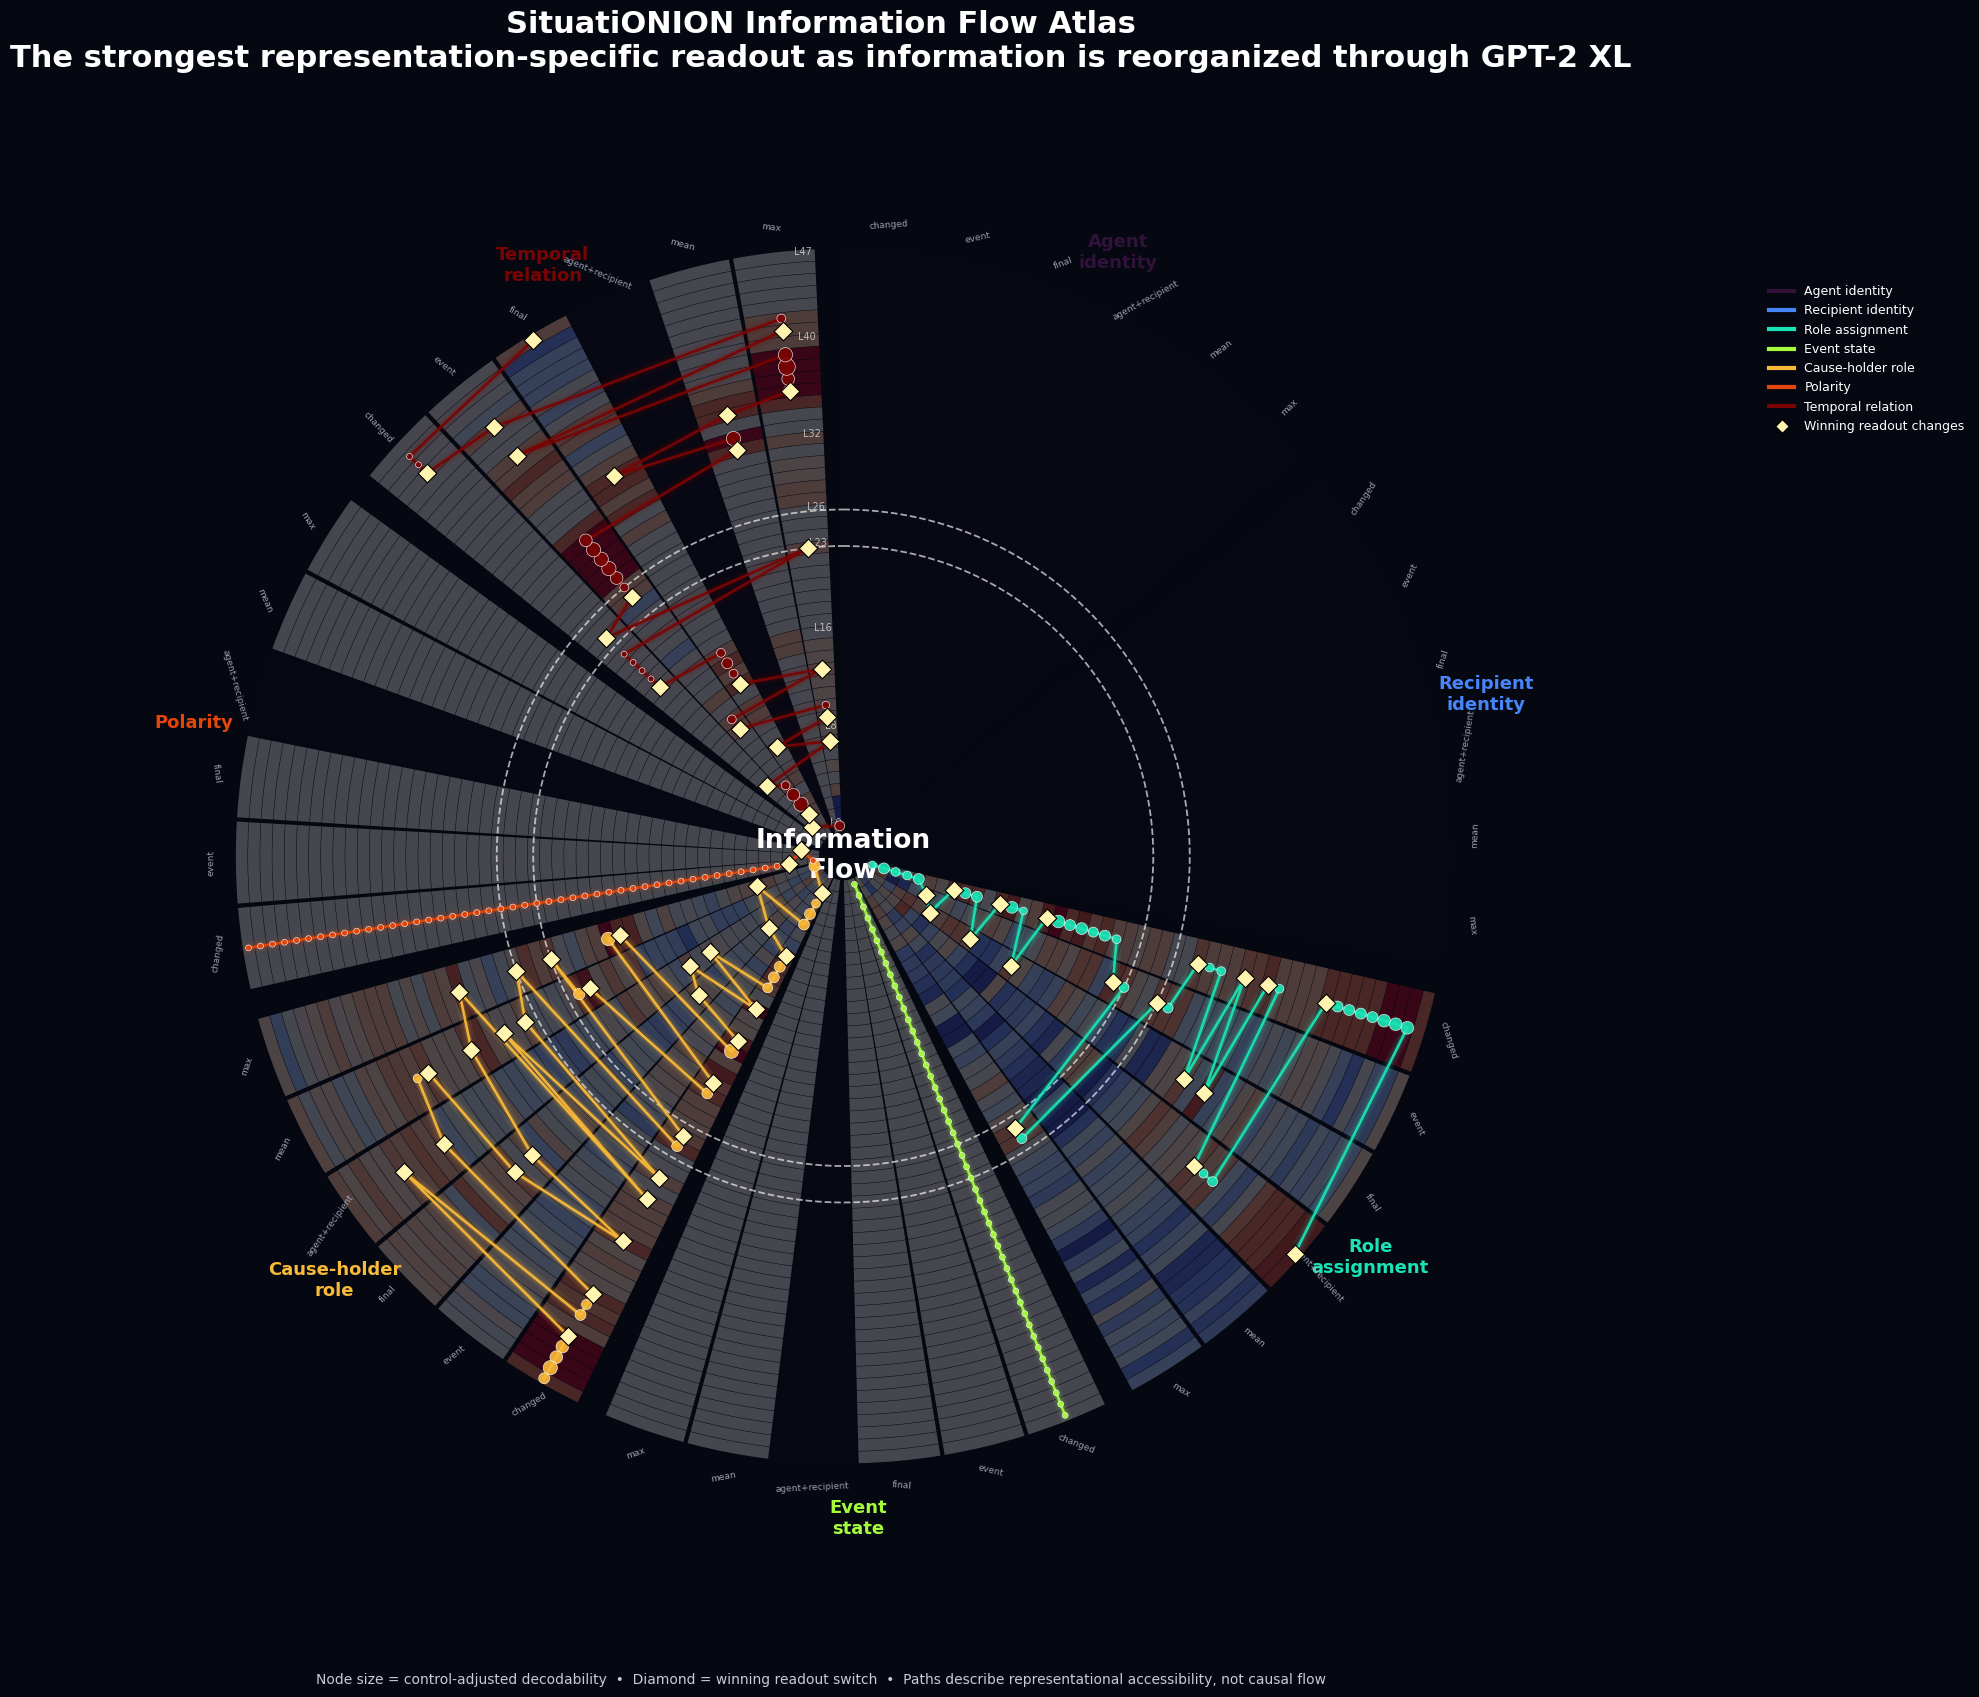

Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/situationion_information_flow_atlas.png
Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/situationion_information_flow_atlas.pdf


In [ ]:
# =============================================================================
# V5.6 — SITUATIONION INFORMATION FLOW ATLAS
# =============================================================================
#
# Shows where each situation variable is most strongly represented as
# information moves through GPT-2 XL.
#
# For every:
#
#     task × layer
#
# select the readout with maximum:
#
#     conservative_advantage
#
# Then connect those best-readout positions through depth.
#
# Interpretation:
#
#     radial direction
#         = transformer depth
#
#     angular movement within each task sector
#         = apparent migration between readout locations
#
#     node size
#         = strength of control-adjusted decodability
#
#     bright transition nodes
#         = change in winning readout
#
# This is descriptive representational flow, NOT causal information flow.
#
# Outputs:
#     situationion_information_flow_atlas.png
#     situationion_information_flow_atlas.pdf
#     information_flow_paths.csv
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


# =============================================================================
# 1. FIND WINNING READOUT FOR EACH TASK × LAYER
# =============================================================================

flow_data = (
    diagnostic
    .query(
        "test_split == @PLOT_SPLIT"
    )
    .dropna(
        subset=[
            "conservative_advantage"
        ]
    )
    .copy()
)


# Keep only task/readout combinations included in our radial layout.
flow_data = flow_data[
    flow_data["task"].isin(
        TASK_ORDER
    )
    &
    flow_data["readout"].isin(
        READOUT_ORDER
    )
]


winning = (
    flow_data
    .sort_values(
        [
            "task",
            "layer",
            "conservative_advantage"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .drop_duplicates(
        [
            "task",
            "layer"
        ]
    )
    .sort_values(
        [
            "task",
            "layer"
        ]
    )
    .copy()
)


# =============================================================================
# 2. IDENTIFY READOUT SWITCHES
# =============================================================================

winning[
    "previous_readout"
] = (
    winning
    .groupby(
        "task"
    )[
        "readout"
    ]
    .shift(1)
)


winning[
    "readout_switch"
] = (
    winning[
        "readout"
    ]
    != winning[
        "previous_readout"
    ]
)


# First layer isn't really a "switch".
winning.loc[
    winning[
        "previous_readout"
    ].isna(),
    "readout_switch"
] = False


flow_csv = (
    DIAGNOSTIC_DIR
    / "information_flow_paths.csv"
)


winning.to_csv(
    flow_csv,
    index=False
)


print(
    "Saved:",
    flow_csv
)


# =============================================================================
# 3. ANGULAR LOOKUP TABLE
# =============================================================================

readout_centers = {}

for wedge_index, (
    task,
    readout
) in enumerate(
    wedge_meta
):

    left, right = theta_edges[
        wedge_index
    ]

    readout_centers[
        (
            task,
            readout
        )
    ] = (
        left
        + right
    ) / 2


# =============================================================================
# 4. CREATE BACKGROUND ONION
# =============================================================================

fig = plt.figure(
    figsize=(18, 18)
)

ax = fig.add_subplot(
    111,
    projection="polar"
)

ax.set_theta_zero_location(
    "N"
)

ax.set_theta_direction(
    -1
)

ax.set_facecolor(
    "#050711"
)

fig.patch.set_facecolor(
    "#050711"
)


# Background representation map.
background_alpha = 0.30

for layer_index, layer in enumerate(
    layers
):

    bottom = (
        radial_inner
        + layer_index
    )

    for wedge_index, (
        theta_left,
        theta_right
    ) in enumerate(
        theta_edges
    ):

        value = Z[
            layer_index,
            wedge_index
        ]

        if np.isnan(value):

            facecolor = (
                0.1,
                0.1,
                0.15,
                0.1
            )

        else:

            rgba = advantage_cmap(
                advantage_norm(
                    value
                )
            )

            facecolor = (
                rgba[0],
                rgba[1],
                rgba[2],
                background_alpha
            )

        ax.bar(
            (
                theta_left
                + theta_right
            ) / 2,
            height=0.96,
            width=(
                theta_right
                - theta_left
            ) * 0.95,
            bottom=bottom,
            color=facecolor,
            edgecolor="none"
        )


# =============================================================================
# 5. TASK PATH COLORS
# =============================================================================

task_cmap = plt.get_cmap(
    "turbo"
)

task_colors = {
    task: task_cmap(
        i / max(
            1,
            len(TASK_ORDER) - 1
        )
    )
    for i, task in enumerate(
        TASK_ORDER
    )
}


# =============================================================================
# 6. DRAW INFORMATION-FLOW PATHS
# =============================================================================

for task in TASK_ORDER:

    task_curve = (
        winning
        .query(
            "task == @task"
        )
        .sort_values(
            "layer"
        )
    )


    if task_curve.empty:
        continue


    theta_values = []
    radius_values = []
    strength_values = []
    switch_values = []


    for _, row in task_curve.iterrows():

        theta = readout_centers[
            (
                task,
                row["readout"]
            )
        ]

        layer_index = np.where(
            layers
            == row["layer"]
        )[0][0]

        radius = (
            radial_inner
            + layer_index
            + 0.5
        )

        theta_values.append(
            theta
        )

        radius_values.append(
            radius
        )

        strength_values.append(
            row[
                "conservative_advantage"
            ]
        )

        switch_values.append(
            row[
                "readout_switch"
            ]
        )


    theta_values = np.asarray(
        theta_values
    )

    radius_values = np.asarray(
        radius_values
    )

    strength_values = np.asarray(
        strength_values
    )


    # ---------------------------------------------------------------------
    # Glow layer
    # ---------------------------------------------------------------------

    ax.plot(
        theta_values,
        radius_values,
        color=task_colors[
            task
        ],
        linewidth=8,
        alpha=0.09,
        zorder=20
    )


    ax.plot(
        theta_values,
        radius_values,
        color=task_colors[
            task
        ],
        linewidth=4,
        alpha=0.18,
        zorder=21
    )


    # ---------------------------------------------------------------------
    # Main trajectory
    # ---------------------------------------------------------------------

    ax.plot(
        theta_values,
        radius_values,
        color=task_colors[
            task
        ],
        linewidth=1.8,
        alpha=0.95,
        zorder=22
    )


    # ---------------------------------------------------------------------
    # Nodes
    # ---------------------------------------------------------------------

    positive_strength = np.clip(
        strength_values,
        0,
        None
    )

    node_sizes = (
        18
        + 260
        * positive_strength
    )


    ax.scatter(
        theta_values,
        radius_values,
        s=node_sizes,
        c=[
            task_colors[
                task
            ]
        ],
        edgecolors="white",
        linewidths=0.45,
        alpha=0.9,
        zorder=24
    )


    # ---------------------------------------------------------------------
    # Readout-switch nodes
    # ---------------------------------------------------------------------

    switches = np.asarray(
        switch_values,
        dtype=bool
    )

    if switches.any():

        ax.scatter(
            theta_values[
                switches
            ],
            radius_values[
                switches
            ],
            s=90,
            marker="D",
            facecolors="#FFF4B0",
            edgecolors="black",
            linewidths=0.8,
            zorder=30
        )


# =============================================================================
# 7. REFERENCE RINGS
# =============================================================================

for layer in [
    23,
    26
]:

    if layer not in layers:
        continue

    layer_index = np.where(
        layers == layer
    )[0][0]

    radius = (
        radial_inner
        + layer_index
        + 0.5
    )

    ax.plot(
        theta_dense,
        np.full_like(
            theta_dense,
            radius
        ),
        color="white",
        linewidth=1.3,
        linestyle="--",
        alpha=0.65,
        zorder=12
    )


# =============================================================================
# 8. TASK SECTOR LABELS
# =============================================================================

for task in TASK_ORDER:

    center = task_centers[
        task
    ]

    ax.text(
        center,
        radial_inner
        + n_layers
        + 4.5,
        TASK_LABELS[
            task
        ],
        ha="center",
        va="center",
        fontsize=13,
        color=task_colors[
            task
        ],
        fontweight="bold"
    )


# =============================================================================
# 9. READOUT LABELS AROUND EDGE
# =============================================================================

for wedge_index, (
    task,
    readout
) in enumerate(
    wedge_meta
):

    left, right = theta_edges[
        wedge_index
    ]

    center = (
        left
        + right
    ) / 2

    rotation = np.degrees(
        center
    )

    if 90 < rotation < 270:
        rotation += 180

    ax.text(
        center,
        radial_inner
        + n_layers
        + 2.0,
        READOUT_LABELS[
            readout
        ],
        rotation=rotation,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=6.5,
        color="#BFC3D4",
        alpha=0.8
    )


# =============================================================================
# 10. LAYER LABELS
# =============================================================================

for layer in [
    0,
    8,
    16,
    23,
    26,
    32,
    40,
    47
]:

    if layer not in layers:
        continue

    layer_index = np.where(
        layers == layer
    )[0][0]

    radius = (
        radial_inner
        + layer_index
        + 0.5
    )

    ax.text(
        np.deg2rad(357),
        radius,
        f"L{layer}",
        color="white",
        fontsize=7,
        alpha=0.65,
        ha="right"
    )


# =============================================================================
# 11. CENTER LABEL
# =============================================================================

ax.text(
    0,
    0,
    "Information\nFlow",
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold",
    color="white"
)


# =============================================================================
# 12. CLEAN AXES
# =============================================================================

ax.set_xticks([])
ax.set_yticks([])

ax.spines[
    "polar"
].set_visible(
    False
)

ax.set_ylim(
    0,
    radial_inner
    + n_layers
    + 7
)


# =============================================================================
# 13. LEGEND
# =============================================================================

legend_handles = []

for task in TASK_ORDER:

    handle = plt.Line2D(
        [0],
        [0],
        color=task_colors[
            task
        ],
        linewidth=3,
        label=TASK_LABELS[
            task
        ].replace(
            "\n",
            " "
        )
    )

    legend_handles.append(
        handle
    )


switch_handle = plt.Line2D(
    [0],
    [0],
    marker="D",
    linestyle="None",
    markerfacecolor="#FFF4B0",
    markeredgecolor="black",
    markersize=7,
    label="Winning readout changes"
)

legend_handles.append(
    switch_handle
)


legend = ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(
        1.16,
        0.92
    ),
    loc="upper left",
    frameon=False,
    fontsize=9
)

for text in legend.get_texts():
    text.set_color(
        "white"
    )


# =============================================================================
# 14. TITLE + SUBTITLE
# =============================================================================

fig.suptitle(
    "SituatiONION Information Flow Atlas\n"
    "The strongest representation-specific readout as information "
    "is reorganized through GPT-2 XL",
    fontsize=22,
    color="white",
    fontweight="bold",
    y=0.965
)


fig.text(
    0.5,
    0.035,
    "Node size = control-adjusted decodability  •  "
    "Diamond = winning readout switch  •  "
    "Paths describe representational accessibility, not causal flow",
    ha="center",
    color="#C8CBD8",
    fontsize=10
)


# =============================================================================
# 15. SAVE
# =============================================================================

flow_png = (
    DIAGNOSTIC_DIR
    / "situationion_information_flow_atlas.png"
)

flow_pdf = (
    DIAGNOSTIC_DIR
    / "situationion_information_flow_atlas.pdf"
)

fig.savefig(
    flow_png,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

fig.savefig(
    flow_pdf,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


print(
    "Saved:",
    flow_png
)

print(
    "Saved:",
    flow_pdf
)

## Information Flow Atlas: Conclusions

This figure shows **which readout gives the strongest result at each of GPT-2 XL's 48 layers (0–47)**. A yellow diamond means that the best readout changed from the previous layer.

The score shown here is the **conservative advantage**:

\[
\text{Linear Probe} - \max(\text{Lexical Control},\text{Random Projection Control})
\]

So, for example, **+0.20 means the full hidden representation performed about 20 percentage points better than the strongest control**. A score near 0 means the controls could perform about as well.

### 1. Relational information changes much more across the network

The clearest result is the difference between **relational information** and simpler information.

| Task | Readout switches (out of 47) | Maximum advantage |
|---|---:|---:|
| **Cause-holder role** | **29** | **+0.333** |
| **Temporal relation** | **22** | **+0.500** |
| **Role assignment** | **18** | **+0.250** |
| **Polarity** | **2** | **+0.042** |
| **Event state** | **0** | **0.000** |

The three relational tasks are:

- **Role assignment:** *Who did what to whom?*
- **Cause-holder role:** *Who or what caused the event?*
- **Temporal relation:** *What happened before or after what?*

Their best readout changes **18–29 times** across the model. In comparison, polarity changes only **2 times**, and event state never changes.

This suggests that **relational information changes where it is most accessible as it moves through GPT-2 XL, while simpler information stays much more stable.**

---

### 2. Cause-holder role changes location the most

Cause-holder has the most switching of any task: **29 switches across 47 layer transitions**.

Its best readout is:

- `changed_token`: **26/48 layers**
- `max_pool`: **7/48**
- `mean_pool`: **7/48**
- `final_token`: **4/48**
- `agent_recipient`: **4/48**

Between **layers 20–40 alone, the winning readout changes 16 times**.

Its largest advantage over the controls is **+0.333 at layer 16 using `changed_token`**.

This suggests that information about **who or what caused an event** is not stored in one consistently best location. The best place to recover it changes repeatedly as the sentence is processed.

---

### 3. Temporal relation has the strongest result in the entire figure

Temporal relation switches readout **22 times**, but its most interesting result is its maximum advantage.

At **layer 38 using `max_pool`**, the conservative advantage reaches:

\[
\mathbf{+0.500}
\]

This is the largest value in the entire Information Flow Atlas. At that location, the full hidden-state representation performs about **50 percentage points better than the strongest control**.

Temporal information is also spread across several readouts:

- `event_token`: **15/48 layers**
- `max_pool`: **12/48**
- `changed_token`: **11/48**
- `final_token`: **7/48**
- `mean_pool`: **3/48**

No single readout dominates most of the network.

This suggests that information about **what happened before or after what** is especially distributed, and where it is easiest to recover depends strongly on the layer.

---

### 4. Role assignment also changes substantially across layers

Role assignment switches readout **18 times**.

`changed_token` is the most common winner at **32/48 layers (~67%)**, but the model still switches to other readouts many times.

Between **layers 20–40**, there are **10 switches**.

Its maximum advantage is **+0.250**, occurring at **layer 16** and again at **layers 44–46**, using `changed_token`.

So information about **who did what to whom** seems to have a preferred location, but that location is not completely stable across the network.

---

### 5. Layers ~20–40 are especially interesting

The middle-to-late layers contain many of the readout changes for the relational tasks.

Between **layers 20–40**:

- Cause-holder: **16 switches**
- Role assignment: **10 switches**
- Temporal relation: **8 switches**
- Polarity: **0 switches**
- Event state: **0 switches**

There are also several relational changes near the reference layers **23 and 26**.

However, the changes do not happen at one exact layer. They occur before, around, and after layers 23 and 26.

So I would describe **layers ~20–40 as a broad transition region for relational information**, rather than claiming that layer 23 or 26 is a specific "situation-model layer."

---

### 6. Event state is almost the exact opposite

Event state has:

- Raw decoding accuracy: **1.000**
- `changed_token` wins at **48/48 layers**
- Readout switches: **0**
- Conservative advantage: **0.000**

So event state is **perfectly decodable**, but the controls can perform just as well and the best readout never changes.

This is important because it shows that **perfect decoding does not automatically mean GPT-2 is doing something complicated internally**.

---

### 7. Polarity shows the same basic pattern

Polarity also has **1.000 raw decoding accuracy**, but:

- `changed_token` wins at **47/48 layers**
- `final_token` wins at only **1/48**
- There are only **2 switches**
- Maximum advantage is only **+0.042**

After layer 2, the winning readout stays the same.

Like event state, polarity is extremely easy to decode but shows very little extra structure beyond what the controls can already recover.

---

### 8. High accuracy is not necessarily the most interesting result

This is probably the most important lesson from this figure.

**Event state and polarity:**

- Raw accuracy: **1.000**
- Maximum advantage: **0.000 / +0.042**
- Switches: **0 / 2**

**Role assignment, cause-holder, and temporal relation:**

- Maximum advantage: **+0.250 / +0.333 / +0.500**
- Switches: **18 / 29 / 22**

So the tasks with the **best raw accuracy actually show the least internal change**.

The relational tasks are more interesting because their information changes depending on **both the layer and where we look inside the model**.

---

### 9. The three relational tasks are also different from each other

The relational tasks do not all behave the same way.

- **Role assignment** prefers `changed_token` at **32/48 layers**, but still switches 18 times.
- **Cause-holder** prefers `changed_token` at **26/48 layers** and switches the most, **29 times**.
- **Temporal relation** is the most spread out across different readouts. No readout wins more than **15/48 layers**.

This suggests that GPT-2 XL may organize **different kinds of relationships in different ways**, rather than having one general location for all situation information.

---

### 10. What this figure does NOT show

The colored paths should not be interpreted as information literally moving from one token to another.

A switch only means:

> **A different readout became the best place for the probe to recover the information at the next layer.**

So this figure shows **changing accessibility of information**, not proven causal information flow.

Activation patching, ablation, or another causal intervention would be needed to test whether these layers and readouts are actually necessary for GPT-2's processing.

Also, **agent identity and recipient identity are missing because `test_both` was not available for those tasks**. Their empty regions are missing data, not zero performance.

---

## Short Summary

The Information Flow Atlas shows a strong difference between **simple information and relational information**.

**Event state and polarity are perfectly decodable (1.000), but barely change across GPT-2 XL and provide almost no advantage over the controls.**

In comparison, **role assignment, cause-holder, and temporal relation switch their strongest readout 18, 29, and 22 times**, and reach maximum advantages of **+0.250, +0.333, and +0.500**.

Many of these changes happen around **layers 20–40**, suggesting that this is an especially interesting region for relational processing.

Overall, my results suggest that **simple properties can stay easy to recover throughout the model, while relationships like who did what to whom, who caused an event, and what happened before or after something else change much more as GPT-2 XL processes the sentence.**

This does **not** yet prove that the information is actually "flowing" along these paths. Instead, it shows **where the information is easiest to detect at different layers**, which gives me specific places to test with causal experiments next.

-----
-----
-----

# V5.7 — Statistical & Implementation Validation

This final section checks three possible weaknesses in the V5 results:

1. **Transition enrichment:** Are relational readout switches unusually concentrated in layers 20–40 or around layers 23–26?
2. **Bootstrap uncertainty:** Are the largest control-adjusted decoding effects stable across held-out examples?
3. **CPU/GPU validation:** Did RAPIDS/cuML acceleration produce results consistent with standard CPU scikit-learn?

These tests are intended to validate the main V5 findings before moving to causal experiments in V6.

In [29]:
# =============================================================================
# V5.7.1 — STATISTICAL VALIDATION:
# TRANSITION ENRICHMENT
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import balanced_accuracy_score


# -------------------------------------------------------------------------
# SETTINGS
# -------------------------------------------------------------------------

N_PERMUTATIONS = 10_000
N_BOOTSTRAPS = 2_000

validation_rng = np.random.default_rng(SEED)

RELATIONAL_TASKS = [
    "role_assignment",
    "cause_holder_role",
    "temporal_relation",
]


# -------------------------------------------------------------------------
# MAKE SURE OUTPUT DIRECTORY EXISTS
# -------------------------------------------------------------------------

DIAGNOSTIC_DIR = OUTPUT_DIR / "diagnostics"
DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------------------------------------------------------
# CHECK THAT V5.6 WAS RUN
# -------------------------------------------------------------------------

if "winning" not in globals():
    raise RuntimeError(
        "The `winning` dataframe does not exist. "
        "Run V5.6 Information Flow Atlas first."
    )


# -------------------------------------------------------------------------
# EXTRACT SWITCH LOCATIONS
# -------------------------------------------------------------------------

switches = (
    winning[
        winning["readout_switch"]
    ][
        [
            "task",
            "layer"
        ]
    ]
    .copy()
)


# -------------------------------------------------------------------------
# PERMUTATION TEST
# -------------------------------------------------------------------------

def transition_enrichment_test(
    switches,
    tasks,
    region_layers,
    n_permutations=10_000,
    seed=SEED
):
    """
    Tests whether readout switches occur inside a layer region
    more often than expected if each task's switches were randomly
    distributed across the 47 possible layer transitions.
    """

    rng = np.random.default_rng(seed)

    possible_layers = np.arange(
        1,
        48
    )

    region_layers = set(
        region_layers
    )

    observed = 0
    task_counts = {}

    for task in tasks:

        task_switches = (
            switches.loc[
                switches["task"] == task,
                "layer"
            ]
            .to_numpy()
        )

        task_counts[task] = len(
            task_switches
        )

        observed += sum(
            layer in region_layers
            for layer in task_switches
        )


    null_counts = np.zeros(
        n_permutations,
        dtype=int
    )


    for i in range(
        n_permutations
    ):

        simulated_total = 0

        for task, n_switches in task_counts.items():

            simulated = rng.choice(
                possible_layers,
                size=n_switches,
                replace=False
            )

            simulated_total += sum(
                layer in region_layers
                for layer in simulated
            )

        null_counts[i] = (
            simulated_total
        )


    p_value = (
        1
        + np.sum(
            null_counts >= observed
        )
    ) / (
        n_permutations + 1
    )


    return {
        "observed": observed,
        "null_mean": float(
            null_counts.mean()
        ),
        "null_sd": float(
            null_counts.std(ddof=1)
        ),
        "p_value": float(
            p_value
        ),
        "null_counts": null_counts
    }


# -------------------------------------------------------------------------
# TEST A — BROAD MIDDLE/LATE REGION
# -------------------------------------------------------------------------

broad_result = (
    transition_enrichment_test(
        switches=switches,
        tasks=RELATIONAL_TASKS,
        region_layers=range(
            20,
            41
        ),
        n_permutations=N_PERMUTATIONS,
        seed=SEED
    )
)


# -------------------------------------------------------------------------
# TEST B — REGION AROUND REFERENCE LAYERS 23 AND 26
#
# 22–27 includes ±1 layer around the two reference points.
# -------------------------------------------------------------------------

reference_result = (
    transition_enrichment_test(
        switches=switches,
        tasks=RELATIONAL_TASKS,
        region_layers=range(
            22,
            28
        ),
        n_permutations=N_PERMUTATIONS,
        seed=SEED + 1
    )
)


# -------------------------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------------------------

transition_validation = pd.DataFrame([
    {
        "region": "layers_20_40",
        "observed_switches":
            broad_result["observed"],
        "null_mean":
            broad_result["null_mean"],
        "null_sd":
            broad_result["null_sd"],
        "p_value":
            broad_result["p_value"]
    },
    {
        "region":
            "layers_22_27_reference_region",
        "observed_switches":
            reference_result["observed"],
        "null_mean":
            reference_result["null_mean"],
        "null_sd":
            reference_result["null_sd"],
        "p_value":
            reference_result["p_value"]
    }
])


display(
    transition_validation
)


transition_validation.to_csv(
    DIAGNOSTIC_DIR
    / "transition_enrichment_validation.csv",
    index=False
)


print("\nTransition tests complete.")

print(
    "\nLayers 20–40:"
)

print(
    f"Observed = "
    f"{broad_result['observed']}"
)

print(
    f"Null mean = "
    f"{broad_result['null_mean']:.2f}"
)

print(
    f"p = "
    f"{broad_result['p_value']:.4f}"
)


print(
    "\nLayers 22–27:"
)

print(
    f"Observed = "
    f"{reference_result['observed']}"
)

print(
    f"Null mean = "
    f"{reference_result['null_mean']:.2f}"
)

print(
    f"p = "
    f"{reference_result['p_value']:.4f}"
)

,region,observed_switches,null_mean,null_sd,p_value
0,layers_20_40,34,30.8451,2.935842,0.179582
1,layers_22_27_reference_region,10,8.7749,1.955713,0.351165



Transition tests complete.

Layers 20–40:
Observed = 34
Null mean = 30.85
p = 0.1796

Layers 22–27:
Observed = 10
Null mean = 8.77
p = 0.3512


In [30]:
# =============================================================================
# V5.7.2 — BOOTSTRAP UNCERTAINTY
# =============================================================================

bootstrap_rng = np.random.default_rng(
    SEED
)


def bootstrap_balanced_accuracy(
    y_true,
    y_pred,
    n_bootstraps=2_000
):
    """
    Stratified bootstrap of balanced accuracy.

    Examples are resampled with replacement within each class
    so that every bootstrap sample contains all classes.
    """

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    classes = np.unique(
        y_true
    )


    class_indices = {
        cls: np.flatnonzero(
            y_true == cls
        )
        for cls in classes
    }


    scores = np.zeros(
        n_bootstraps,
        dtype=float
    )


    for i in range(
        n_bootstraps
    ):

        sampled_indices = (
            np.concatenate([
                bootstrap_rng.choice(
                    indices,
                    size=len(indices),
                    replace=True
                )
                for indices
                in class_indices.values()
            ])
        )


        scores[i] = (
            balanced_accuracy_score(
                y_true[
                    sampled_indices
                ],
                y_pred[
                    sampled_indices
                ]
            )
        )


    estimate = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    return {
        "estimate": float(
            estimate
        ),
        "ci_low": float(
            np.quantile(
                scores,
                0.025
            )
        ),
        "ci_high": float(
            np.quantile(
                scores,
                0.975
            )
        ),
        "bootstrap_scores":
            scores
    }


# -------------------------------------------------------------------------
# GET PREDICTIONS FROM ONE V5 PROBE CONFIGURATION
# -------------------------------------------------------------------------

def get_probe_predictions(
    task,
    readout,
    layer,
    test_split="test_both"
):
    """
    Refit the original V5 probe on the dev split
    and return predictions on the requested held-out split.
    """

    label, flag = TASKS[
        task
    ]


    data = (
        probe_examples[
            probe_examples[
                flag
            ]
        ]
        .copy()
    )


    train = data.loc[
        data["split"] == "dev"
    ]


    test = data.loc[
        data["split"] == test_split
    ]


    if len(test) == 0:
        raise ValueError(
            f"No examples for "
            f"{task} / {test_split}"
        )


    x_train, y_train = (
        get_representation_subset(
            train.index.to_numpy(),
            train[label].to_numpy(),
            readout,
            layer
        )
    )


    x_test, y_test = (
        get_representation_subset(
            test.index.to_numpy(),
            test[label].to_numpy(),
            readout,
            layer
        )
    )


    if (
        x_train is None
        or x_test is None
    ):
        raise ValueError(
            "Representation subset "
            "could not be created."
        )


    scaler, probe = fit_probe(
        x_train,
        y_train
    )


    if (
        scaler is None
        or probe is None
    ):
        raise ValueError(
            "Probe could not be fit."
        )


    x_test_scaled = (
        scaler.transform(
            x_test
        )
    )


    y_pred = probe.predict(
        x_test_scaled
    )


    return (
        np.asarray(
            y_test
        ),
        np.asarray(
            y_pred
        )
    )


print(
    "Bootstrap helper functions ready."
)

Bootstrap helper functions ready.


In [31]:
# =============================================================================
# V5.7.3 — BOOTSTRAP HEADLINE RESULTS
# =============================================================================

HEADLINE_CONFIGS = [

    # Strongest temporal result
    {
        "task":
            "temporal_relation",
        "readout":
            "max_pool",
        "layer":
            38,
        "test_split":
            "test_both"
    },

    # Strongest cause-holder result
    {
        "task":
            "cause_holder_role",
        "readout":
            "changed_token",
        "layer":
            16,
        "test_split":
            "test_both"
    },

    # Strong role-assignment result
    {
        "task":
            "role_assignment",
        "readout":
            "changed_token",
        "layer":
            16,
        "test_split":
            "test_both"
    },

    # Simple-variable comparison
    {
        "task":
            "event_state",
        "readout":
            "changed_token",
        "layer":
            24,
        "test_split":
            "test_both"
    },

    # Simple-variable comparison
    {
        "task":
            "polarity",
        "readout":
            "changed_token",
        "layer":
            24,
        "test_split":
            "test_both"
    }
]


bootstrap_rows = []


for config in HEADLINE_CONFIGS:

    print(
        "\nBootstrapping:",
        config["task"],
        "|",
        config["readout"],
        "| layer",
        config["layer"]
    )


    y_true, y_pred = (
        get_probe_predictions(
            **config
        )
    )


    result = (
        bootstrap_balanced_accuracy(
            y_true,
            y_pred,
            n_bootstraps=N_BOOTSTRAPS
        )
    )


    bootstrap_rows.append({
        **config,

        "n_test":
            len(y_true),

        "balanced_accuracy":
            result[
                "estimate"
            ],

        "ci_low":
            result[
                "ci_low"
            ],

        "ci_high":
            result[
                "ci_high"
            ]
    })


bootstrap_validation = (
    pd.DataFrame(
        bootstrap_rows
    )
)


display(
    bootstrap_validation
)


bootstrap_validation.to_csv(
    DIAGNOSTIC_DIR
    / "bootstrap_validation.csv",
    index=False
)


print(
    "\nBootstrap validation complete."
)

print(
    "Saved:",
    DIAGNOSTIC_DIR
    / "bootstrap_validation.csv"
)


Bootstrapping: temporal_relation | max_pool | layer 38

Bootstrapping: cause_holder_role | changed_token | layer 16

Bootstrapping: role_assignment | changed_token | layer 16

Bootstrapping: event_state | changed_token | layer 24

Bootstrapping: polarity | changed_token | layer 24


,task,readout,layer,test_split,n_test,balanced_accuracy,ci_low,ci_high
0,temporal_relation,max_pool,38,test_both,18,1.0,1.0,1.0
1,cause_holder_role,changed_token,16,test_both,36,1.0,1.0,1.0
2,role_assignment,changed_token,16,test_both,18,1.0,1.0,1.0
3,event_state,changed_token,24,test_both,18,1.0,1.0,1.0
4,polarity,changed_token,24,test_both,18,1.0,1.0,1.0



Bootstrap validation complete.
Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/bootstrap_validation.csv


In [37]:
# =============================================================================
# V5.7.2.1 — PAIRED BOOTSTRAP OF CONSERVATIVE CONTROL ADVANTAGE
# =============================================================================
#
# Tests the quantity V5 actually cares about:
#
#   conservative advantage =
#       linear balanced accuracy
#       - strongest nonchance control balanced accuracy
#
# strongest nonchance control =
#       max(lexical, random_projection)
#
# IMPORTANT:
# The strongest control is selected from the ORIGINAL V5 atlas,
# not separately inside each bootstrap replicate.
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.random_projection import GaussianRandomProjection


N_BOOTSTRAPS = 5000


# -----------------------------------------------------------------------------
# Utility
# -----------------------------------------------------------------------------

def _to_numpy(x):
    """
    Safely convert CPU/GPU-like arrays to NumPy.
    """
    if hasattr(x, "get"):
        x = x.get()

    return np.asarray(x)


# -----------------------------------------------------------------------------
# Find the original V5 diagnostic row
# -----------------------------------------------------------------------------

def get_diagnostic_row(
    task,
    readout,
    layer,
    test_split
):
    """
    Retrieve the exact task/readout/layer/split row from the
    V5.4 diagnostic dataframe.
    """

    rows = diagnostic[
        (diagnostic["task"] == task)
        & (diagnostic["readout"] == readout)
        & (diagnostic["layer"] == layer)
        & (diagnostic["test_split"] == test_split)
    ].copy()

    if len(rows) != 1:
        raise ValueError(
            f"Expected exactly one diagnostic row for "
            f"{task} / {readout} / L{layer} / {test_split}, "
            f"but found {len(rows)}."
        )

    return rows.iloc[0]


# -----------------------------------------------------------------------------
# Refit the original linear probe and return held-out predictions
# -----------------------------------------------------------------------------

def get_linear_predictions(
    task,
    readout,
    layer,
    test_split="test_both"
):
    """
    Refit the original V5 linear probe on dev and return
    held-out predictions.
    """

    label, flag = TASKS[task]

    data = (
        probe_examples[
            probe_examples[flag]
        ]
        .copy()
    )

    train = data.loc[
        data["split"] == "dev"
    ]

    test = data.loc[
        data["split"] == test_split
    ]

    if len(test) == 0:
        raise ValueError(
            f"No examples for {task} / {test_split}"
        )

    x_train, y_train = get_representation_subset(
        train.index.to_numpy(),
        train[label].to_numpy(),
        readout,
        layer
    )

    x_test, y_test = get_representation_subset(
        test.index.to_numpy(),
        test[label].to_numpy(),
        readout,
        layer
    )

    scaler, probe = fit_probe(
        x_train,
        y_train
    )

    x_test_scaled = scaler.transform(
        x_test
    )

    y_pred = probe.predict(
        x_test_scaled
    )

    return (
        _to_numpy(y_test),
        _to_numpy(y_pred),
        train,
        test,
        label
    )


# -----------------------------------------------------------------------------
# Lexical control
# -----------------------------------------------------------------------------
def get_lexical_predictions(
    train,
    test,
    label
):
    """
    Reconstruct EXACTLY the lexical control used in V4.5.
    """

    y_train = train[
        label
    ].to_numpy()

    y_test = test[
        label
    ].to_numpy()


    # EXACT original V4.5 TF-IDF settings
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        dtype=np.float32
    )


    x_train_tfidf = tfidf.fit_transform(
        train["text"]
    )


    # EXACT original V4.5 probe fitting
    tfidf_scaler, tfidf_probe = fit_probe(
        x_train_tfidf,
        y_train
    )


    x_test_tfidf = tfidf.transform(
        test["text"]
    )


    x_test_scaled = tfidf_scaler.transform(
        x_test_tfidf
    )


    predictions = tfidf_probe.predict(
        x_test_scaled
    )


    return (
        np.asarray(y_test),
        _to_numpy(predictions)
    )

# -----------------------------------------------------------------------------
# Random-projection control
# -----------------------------------------------------------------------------
def get_random_projection_predictions(
    task,
    readout,
    layer,
    train,
    test,
    label
):
    """
    Reconstruct EXACTLY the random-projection control used in V4.5.

    IMPORTANT:
    This reuses projected_cache rather than creating a new random
    projection. The original cache was created once per readout/layer
    using random_state=SEED.
    """

    train_indices = (
        train.index.to_numpy()
    )

    test_indices = (
        test.index.to_numpy()
    )

    y_train_raw = (
        train[label].to_numpy()
    )

    y_test_raw = (
        test[label].to_numpy()
    )


    # ---------------------------------------------------------------------
    # EXACT original V4.5 projected DEV matrix
    # ---------------------------------------------------------------------

    x_train_rp, y_train_rp = (
        get_projected_subset(
            train_indices,
            y_train_raw,
            readout,
            layer
        )
    )


    if (
        x_train_rp is None
        or len(
            np.unique(
                y_train_rp
            )
        ) < 2
    ):
        raise ValueError(
            f"Could not fit random-projection control for "
            f"{task} / {readout} / layer {layer}"
        )


    # EXACT original V4.5 probe
    rp_scaler, rp_probe = fit_probe(
        x_train_rp,
        y_train_rp
    )


    # ---------------------------------------------------------------------
    # EXACT original V4.5 projected held-out matrix
    # ---------------------------------------------------------------------

    x_test_rp, y_test_rp = (
        get_projected_subset(
            test_indices,
            y_test_raw,
            readout,
            layer
        )
    )


    if x_test_rp is None:
        raise ValueError(
            f"No projected test representations for "
            f"{task} / {readout} / layer {layer}"
        )


    x_test_scaled = (
        rp_scaler.transform(
            x_test_rp
        )
    )


    predictions = rp_probe.predict(
        x_test_scaled
    )


    return (
        _to_numpy(y_test_rp),
        _to_numpy(predictions)
    )

# -----------------------------------------------------------------------------
# Get paired linear/control predictions
# -----------------------------------------------------------------------------
def get_paired_predictions(
    task,
    readout,
    layer,
    test_split="test_both"
):
    """
    Returns predictions from:

        1. full hidden-state linear probe
        2. strongest original V5 nonchance control

    The control identity is determined from the ORIGINAL
    diagnostic scores.
    """

    diagnostic_row = get_diagnostic_row(
        task,
        readout,
        layer,
        test_split
    )

    lexical_score = float(
        diagnostic_row["lexical_score"]
    )

    rp_score = float(
        diagnostic_row["random_projection_score"]
    )

    if lexical_score >= rp_score:
        strongest_control = "lexical"
    else:
        strongest_control = "random_projection"

    (
        y_true,
        linear_pred,
        train,
        test,
        label
    ) = get_linear_predictions(
        task,
        readout,
        layer,
        test_split
    )

    # ---------------------------------------------------------------------
    # STRONGEST CONTROL PREDICTIONS
    # ---------------------------------------------------------------------

    if strongest_control == "lexical":

        (
            control_y,
            control_pred
        ) = get_lexical_predictions(
            train,
            test,
            label
        )

    else:

        (
            control_y,
            control_pred
        ) = get_random_projection_predictions(
            task,
            readout,
            layer,
            train,
            test,
            label
        )

    control_y = _to_numpy(
        control_y
    )

    control_pred = _to_numpy(
        control_pred
    )

    # ---------------------------------------------------------------------
    # ALIGNMENT CHECK
    # ---------------------------------------------------------------------

    if not np.array_equal(
        y_true,
        control_y
    ):
        raise RuntimeError(
            "Linear and control labels are not aligned."
        )

    # ---------------------------------------------------------------------
    # RECONSTRUCT SCORES
    # ---------------------------------------------------------------------

    linear_score = balanced_accuracy_score(
        y_true,
        linear_pred
    )

    reconstructed_control_score = balanced_accuracy_score(
        y_true,
        control_pred
    )

    atlas_control_score = max(
        lexical_score,
        rp_score
    )

    return {
        "y_true": y_true,
        "linear_pred": linear_pred,
        "control_pred": control_pred,

        "strongest_control":
            strongest_control,

        "linear_score":
            float(linear_score),

        "control_score":
            float(reconstructed_control_score),

        "atlas_linear_score":
            float(
                diagnostic_row["linear_score"]
            ),

        "atlas_control_score":
            float(atlas_control_score),

        "atlas_conservative_advantage":
            float(
                diagnostic_row[
                    "conservative_advantage"
                ]
            )
    }

# -----------------------------------------------------------------------------
# Paired stratified bootstrap
# -----------------------------------------------------------------------------

def bootstrap_paired_advantage(
    y_true,
    linear_pred,
    control_pred,
    n_bootstraps=5000,
    seed=SEED
):
    """
    Stratified paired bootstrap.

    The SAME resampled held-out examples are used to calculate
    both linear and control balanced accuracy.

    Bootstrap statistic:

        BA(linear) - BA(control)
    """

    rng = np.random.default_rng(
        seed
    )

    y_true = _to_numpy(
        y_true
    )

    linear_pred = _to_numpy(
        linear_pred
    )

    control_pred = _to_numpy(
        control_pred
    )

    classes = np.unique(
        y_true
    )

    class_indices = {
        cls: np.flatnonzero(
            y_true == cls
        )
        for cls in classes
    }

    bootstrap_advantages = np.zeros(
        n_bootstraps,
        dtype=float
    )

    for i in range(
        n_bootstraps
    ):

        sampled_indices = np.concatenate([
            rng.choice(
                indices,
                size=len(indices),
                replace=True
            )
            for indices
            in class_indices.values()
        ])

        boot_y = y_true[
            sampled_indices
        ]

        boot_linear = linear_pred[
            sampled_indices
        ]

        boot_control = control_pred[
            sampled_indices
        ]

        linear_score = balanced_accuracy_score(
            boot_y,
            boot_linear
        )

        control_score = balanced_accuracy_score(
            boot_y,
            boot_control
        )

        bootstrap_advantages[i] = (
            linear_score
            - control_score
        )

    observed_linear = balanced_accuracy_score(
        y_true,
        linear_pred
    )

    observed_control = balanced_accuracy_score(
        y_true,
        control_pred
    )

    observed_advantage = (
        observed_linear
        - observed_control
    )

    ci_low = np.quantile(
        bootstrap_advantages,
        0.025
    )

    ci_high = np.quantile(
        bootstrap_advantages,
        0.975
    )

    # Fraction of bootstrap replicates <= 0.
    # This is useful descriptive evidence about whether the
    # observed advantage remains positive under resampling.
    probability_nonpositive = (
        np.mean(
            bootstrap_advantages <= 0
        )
    )

    return {
        "linear_score":
            float(observed_linear),

        "control_score":
            float(observed_control),

        "advantage":
            float(observed_advantage),

        "ci_low":
            float(ci_low),

        "ci_high":
            float(ci_high),

        "bootstrap_p_nonpositive":
            float(probability_nonpositive),

        "bootstrap_advantages":
            bootstrap_advantages
    }


print(
    "V5.7 paired conservative-advantage "
    "bootstrap helpers ready."
)

V5.7 paired conservative-advantage bootstrap helpers ready.


In [38]:
print(
    "projected_cache exists:",
    "projected_cache" in globals()
)

if "projected_cache" in globals():
    print(
        "Cached matrices:",
        len(projected_cache)
    )

projected_cache exists: True
Cached matrices: 288


In [39]:
# =============================================================================
# V5.7.3.1 — RUN PAIRED CONSERVATIVE-ADVANTAGE BOOTSTRAP
# =============================================================================

HEADLINE_CONFIGS = [

    # Strongest temporal conservative advantage
    {
        "task": "temporal_relation",
        "readout": "max_pool",
        "layer": 38,
        "test_split": "test_both"
    },

    # Strongest cause-holder result
    {
        "task": "cause_holder_role",
        "readout": "changed_token",
        "layer": 16,
        "test_split": "test_both"
    },

    # Strong role-assignment result
    {
        "task": "role_assignment",
        "readout": "changed_token",
        "layer": 16,
        "test_split": "test_both"
    },

    # Simple-information comparison
    {
        "task": "event_state",
        "readout": "changed_token",
        "layer": 24,
        "test_split": "test_both"
    },

    # Simple-information comparison
    {
        "task": "polarity",
        "readout": "changed_token",
        "layer": 24,
        "test_split": "test_both"
    }
]


bootstrap_rows = []

# Keep distributions so we can make a better figure later.
bootstrap_distributions = {}


for i, config in enumerate(
    HEADLINE_CONFIGS
):

    print(
        "\n" + "=" * 70
    )

    print(
        f"{config['task']} | "
        f"{config['readout']} | "
        f"layer {config['layer']}"
    )


    # ---------------------------------------------------------------------
    # Get matched predictions
    # ---------------------------------------------------------------------

    paired = get_paired_predictions(
        **config
    )


    # ---------------------------------------------------------------------
    # Sanity check against original atlas
    # ---------------------------------------------------------------------

    print(
        f"Strongest control: "
        f"{paired['strongest_control']}"
    )

    print(
        f"Atlas linear score: "
        f"{paired['atlas_linear_score']:.4f}"
    )

    print(
        f"Reconstructed linear score: "
        f"{paired['linear_score']:.4f}"
    )

    print(
        f"Atlas strongest-control score: "
        f"{paired['atlas_control_score']:.4f}"
    )

    print(
        f"Reconstructed control score: "
        f"{paired['control_score']:.4f}"
    )


    # ---------------------------------------------------------------------
    # Warn if reconstruction does not match original atlas
    # ---------------------------------------------------------------------

    linear_difference = abs(
        paired["linear_score"]
        - paired["atlas_linear_score"]
    )

    control_difference = abs(
        paired["control_score"]
        - paired["atlas_control_score"]
    )


    if linear_difference > 1e-6:

        print(
            "WARNING: reconstructed linear score "
            "does not exactly match atlas."
        )


    if control_difference > 1e-6:

        print(
            "WARNING: reconstructed control score "
            "does not exactly match atlas."
        )

        print(
            "Do NOT interpret the bootstrap CI until "
            "the control reconstruction matches V5."
        )


    # ---------------------------------------------------------------------
    # Paired bootstrap
    # ---------------------------------------------------------------------

    result = bootstrap_paired_advantage(
        paired["y_true"],
        paired["linear_pred"],
        paired["control_pred"],
        n_bootstraps=N_BOOTSTRAPS,
        seed=stable_probe_seed(
            config["task"],
            config["readout"],
            config["layer"]
        )
    )


    config_name = (
        f"{config['task']}"
        f"_L{config['layer']}"
        f"_{config['readout']}"
    )


    bootstrap_distributions[
        config_name
    ] = result[
        "bootstrap_advantages"
    ]


    bootstrap_rows.append({

        **config,

        "n_test":
            len(
                paired["y_true"]
            ),

        "strongest_control":
            paired[
                "strongest_control"
            ],

        "linear_score":
            result[
                "linear_score"
            ],

        "control_score":
            result[
                "control_score"
            ],

        "conservative_advantage":
            result[
                "advantage"
            ],

        "ci_low":
            result[
                "ci_low"
            ],

        "ci_high":
            result[
                "ci_high"
            ],

        "bootstrap_fraction_nonpositive":
            result[
                "bootstrap_p_nonpositive"
            ],

        "atlas_conservative_advantage":
            paired[
                "atlas_conservative_advantage"
            ],

        "reconstruction_error":
            abs(
                result["advantage"]
                - paired[
                    "atlas_conservative_advantage"
                ]
            )
    })


    print(
        "\nPaired bootstrap result:"
    )

    print(
        f"Linear BA = "
        f"{result['linear_score']:.4f}"
    )

    print(
        f"Control BA = "
        f"{result['control_score']:.4f}"
    )

    print(
        f"Advantage = "
        f"{result['advantage']:+.4f}"
    )

    print(
        f"95% bootstrap CI = "
        f"[{result['ci_low']:+.4f}, "
        f"{result['ci_high']:+.4f}]"
    )

    print(
        f"Bootstrap fraction <= 0 = "
        f"{result['bootstrap_p_nonpositive']:.4f}"
    )


# =============================================================================
# SUMMARY TABLE
# =============================================================================

bootstrap_validation = pd.DataFrame(
    bootstrap_rows
)


print(
    "\n" + "=" * 70
)

print(
    "V5.7 PAIRED BOOTSTRAP SUMMARY"
)

print(
    "=" * 70
)


display(
    bootstrap_validation[
        [
            "task",
            "readout",
            "layer",
            "n_test",
            "strongest_control",
            "linear_score",
            "control_score",
            "conservative_advantage",
            "ci_low",
            "ci_high",
            "bootstrap_fraction_nonpositive",
            "reconstruction_error"
        ]
    ]
)


# =============================================================================
# SAVE
# =============================================================================

BOOTSTRAP_PATH = (
    DIAGNOSTIC_DIR
    / "paired_conservative_advantage_bootstrap.csv"
)


bootstrap_validation.to_csv(
    BOOTSTRAP_PATH,
    index=False
)


print(
    "\nSaved:",
    BOOTSTRAP_PATH
)


temporal_relation | max_pool | layer 38
Strongest control: lexical
Atlas linear score: 1.0000
Reconstructed linear score: 1.0000
Atlas strongest-control score: 0.5000
Reconstructed control score: 0.5000

Paired bootstrap result:
Linear BA = 1.0000
Control BA = 0.5000
Advantage = +0.5000
95% bootstrap CI = [+0.5000, +0.5000]
Bootstrap fraction <= 0 = 0.0000

cause_holder_role | changed_token | layer 16
Strongest control: random_projection
Atlas linear score: 1.0000
Reconstructed linear score: 1.0000
Atlas strongest-control score: 0.6667
Reconstructed control score: 0.6667

Paired bootstrap result:
Linear BA = 1.0000
Control BA = 0.6667
Advantage = +0.3333
95% bootstrap CI = [+0.1870, +0.5000]
Bootstrap fraction <= 0 = 0.0000

role_assignment | changed_token | layer 16
Strongest control: random_projection
Atlas linear score: 1.0000
Reconstructed linear score: 1.0000
Atlas strongest-control score: 0.7500
Reconstructed control score: 0.7500

Paired bootstrap result:
Linear BA = 1.0000
Con

,task,readout,layer,n_test,strongest_control,linear_score,control_score,conservative_advantage,ci_low,ci_high,bootstrap_fraction_nonpositive,reconstruction_error
0,temporal_relation,max_pool,38,18,lexical,1.0,0.500000,0.500000,0.500000,0.500000,0.0000,0.0
1,cause_holder_role,changed_token,16,36,random_projection,1.0,0.666667,0.333333,0.186979,0.500000,0.0000,0.0
2,role_assignment,changed_token,16,18,random_projection,1.0,0.750000,0.250000,0.083333,0.458333,0.0022,0.0
3,event_state,changed_token,24,18,lexical,1.0,1.000000,0.000000,0.000000,0.000000,1.0000,0.0
4,polarity,changed_token,24,18,random_projection,1.0,1.000000,0.000000,0.000000,0.000000,1.0000,0.0



Saved: /content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/paired_conservative_advantage_bootstrap.csv


### V5.7 Statistical Validation Findings

The paired bootstrap analysis tested whether the full hidden-state probe
outperformed the strongest nonchance control for several representative
results.

The three relational tasks showed positive control-adjusted advantages:

- **Temporal relation:** +0.500, 95% bootstrap CI [0.500, 0.500]
- **Cause-holder role:** +0.333, 95% bootstrap CI [0.187, 0.500]
- **Role assignment:** +0.250, 95% bootstrap CI [0.083, 0.458]

In contrast, **event state** and **polarity** both had an advantage of 0.000
because their strongest controls also reached perfect balanced accuracy.

This strengthens the distinction between simple and relational information
in V5. Simple variables can be decoded perfectly, but the controls can also
decode them perfectly. For the selected relational configurations, the full
hidden representation contains information that is less well preserved by
the strongest lexical or random-projection control.

The temporal-relation bootstrap interval did not vary across resamples.
This should not be interpreted as zero population uncertainty. The held-out
set contains only 18 examples, and the fixed prediction pattern produced the
same balanced-accuracy difference under every class-stratified bootstrap
sample.

These results are still observational. They show differences in
**decodability**, not that these representations are causally required for
the model's behavior.

The earlier transition-enrichment tests also found no significant evidence
that relational readout changes are specifically concentrated in layers
20–40 (p = 0.180) or around layers 22–27 (p = 0.351). Therefore, V5 supports
distributed changes in relational accessibility across depth rather than a
single statistically localized transition layer.

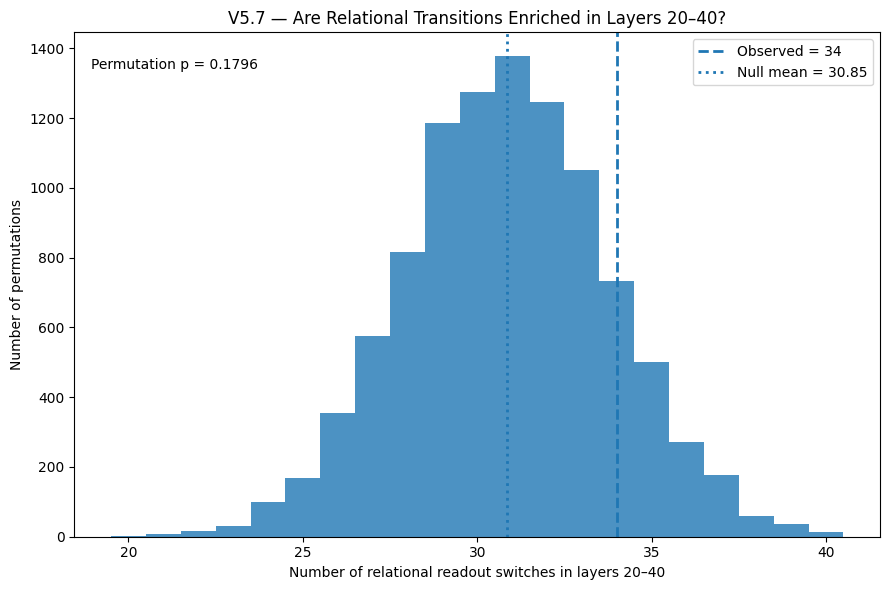

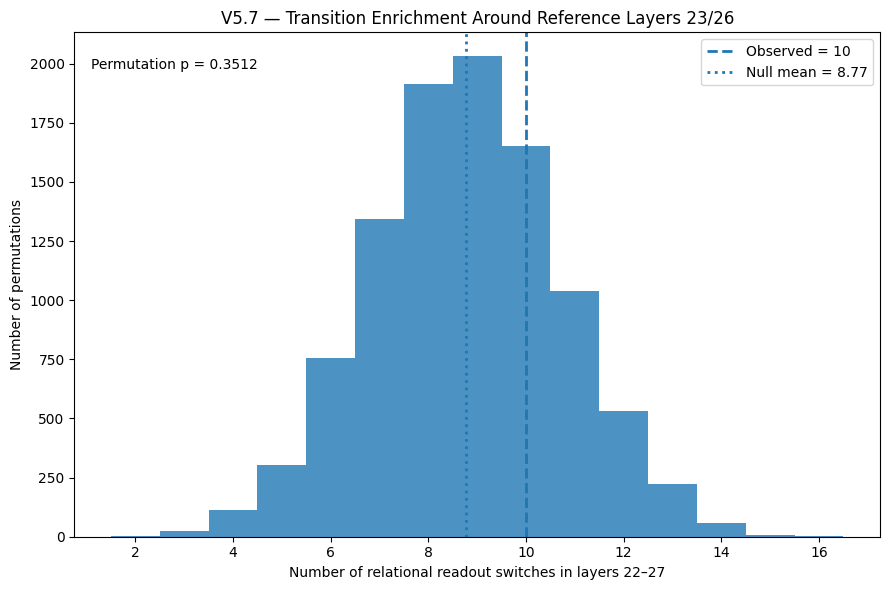

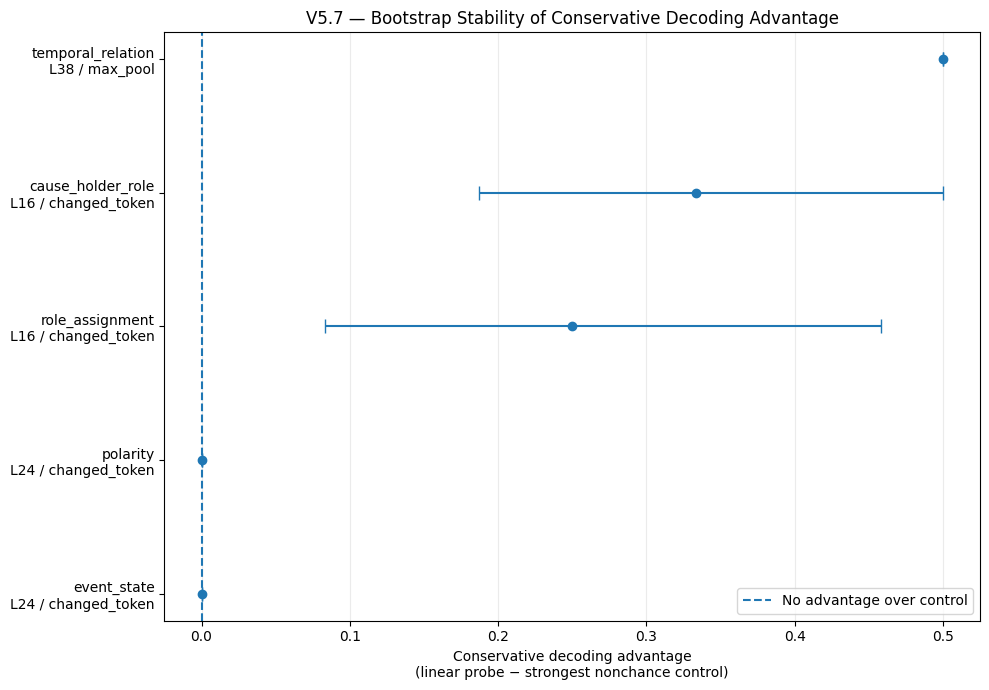


CPU/GPU figure skipped for now.
Run the independent CPU validation later, then re-run this exact cell.

V5.7 VALIDATION REPORT COMPLETE

Figures generated: 3
 • 01_transition_enrichment_layers_20_40.png
 • 02_transition_enrichment_layers_22_27.png
 • 03_paired_conservative_advantage_bootstrap.png

Combined PDF:
/content/drive/MyDrive/Fall26/Coding/SituationionArtifacts/v5_decodability/diagnostics/v5_7_validation/V5_7_Statistical_Validation_Report.pdf

Report status:
 ✓ Transition permutation validation
 ✓ Paired conservative-advantage bootstrap
 ○ CPU/GPU implementation validation pending

PRE-CPU VALIDATION CHECKPOINT REPORT


In [40]:
# =============================================================================
# V5.7.4 — GENERATE VALIDATION FIGURES + COMBINED PDF REPORT
# =============================================================================
#
# Produces:
#
#   Figure 1 — Transition enrichment, layers 20–40
#   Figure 2 — Transition enrichment, reference region 22–27
#   Figure 3 — Paired bootstrap of conservative decoding advantage
#   Figure 4 — CPU vs GPU validation (if results are available)
#
# Then combines all available figures into:
#
#   V5_7_Statistical_Validation_Report.pdf
#
# NOTE:
# CPU/GPU validation is optional at this stage.
# If its CSV does not exist yet, Figure 4 is skipped automatically.
# =============================================================================


# =============================================================================
# IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages


# =============================================================================
# OUTPUT LOCATIONS
# =============================================================================

V57_DIR = (
    DIAGNOSTIC_DIR
    / "v5_7_validation"
)

V57_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PDF_PATH = (
    V57_DIR
    / "V5_7_Statistical_Validation_Report.pdf"
)

generated_figures = []


# =============================================================================
# FIGURE 1 — TRANSITION ENRICHMENT: LAYERS 20–40
# =============================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.hist(
    broad_result["null_counts"],
    bins=np.arange(
        broad_result["null_counts"].min() - 0.5,
        broad_result["null_counts"].max() + 1.5
    ),
    alpha=0.8
)


ax.axvline(
    broad_result["observed"],
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed = "
        f"{broad_result['observed']}"
    )
)


ax.axvline(
    broad_result["null_mean"],
    linestyle=":",
    linewidth=2,
    label=(
        f"Null mean = "
        f"{broad_result['null_mean']:.2f}"
    )
)


ax.set_xlabel(
    "Number of relational readout switches in layers 20–40"
)


ax.set_ylabel(
    "Number of permutations"
)


ax.set_title(
    "V5.7 — Are Relational Transitions Enriched in Layers 20–40?"
)


ax.legend()


ax.text(
    0.02,
    0.95,
    (
        f"Permutation p = "
        f"{broad_result['p_value']:.4f}"
    ),
    transform=ax.transAxes,
    va="top"
)


fig.tight_layout()


path = (
    V57_DIR
    / "01_transition_enrichment_layers_20_40.png"
)


fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


generated_figures.append(
    path
)


plt.show()


# =============================================================================
# FIGURE 2 — TRANSITION ENRICHMENT AROUND REFERENCE LAYERS 23/26
# =============================================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.hist(
    reference_result["null_counts"],
    bins=np.arange(
        reference_result["null_counts"].min() - 0.5,
        reference_result["null_counts"].max() + 1.5
    ),
    alpha=0.8
)


ax.axvline(
    reference_result["observed"],
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed = "
        f"{reference_result['observed']}"
    )
)


ax.axvline(
    reference_result["null_mean"],
    linestyle=":",
    linewidth=2,
    label=(
        f"Null mean = "
        f"{reference_result['null_mean']:.2f}"
    )
)


ax.set_xlabel(
    "Number of relational readout switches in layers 22–27"
)


ax.set_ylabel(
    "Number of permutations"
)


ax.set_title(
    "V5.7 — Transition Enrichment Around Reference Layers 23/26"
)


ax.legend()


ax.text(
    0.02,
    0.95,
    (
        f"Permutation p = "
        f"{reference_result['p_value']:.4f}"
    ),
    transform=ax.transAxes,
    va="top"
)


fig.tight_layout()


path = (
    V57_DIR
    / "02_transition_enrichment_layers_22_27.png"
)


fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)


generated_figures.append(
    path
)


plt.show()


# =============================================================================
# FIGURE 3 — PAIRED CONSERVATIVE-ADVANTAGE BOOTSTRAP
# =============================================================================
#
# This is the corrected V5.7 bootstrap figure.
#
# It plots:
#
#   full hidden-state balanced accuracy
#       MINUS
#   strongest nonchance-control balanced accuracy
#
# rather than raw probe accuracy.
# =============================================================================

if "bootstrap_validation" in globals():

    required_bootstrap_columns = {
        "task",
        "readout",
        "layer",
        "conservative_advantage",
        "ci_low",
        "ci_high"
    }


    if required_bootstrap_columns.issubset(
        bootstrap_validation.columns
    ):

        plot_df = (
            bootstrap_validation
            .copy()
            .sort_values(
                "conservative_advantage"
            )
            .reset_index(
                drop=True
            )
        )


        plot_df["label"] = (
            plot_df["task"]
            + "\nL"
            + plot_df["layer"].astype(str)
            + " / "
            + plot_df["readout"]
        )


        y = np.arange(
            len(plot_df)
        )


        estimates = (
            plot_df[
                "conservative_advantage"
            ]
            .to_numpy()
        )


        lower = (
            estimates
            - plot_df[
                "ci_low"
            ].to_numpy()
        )


        upper = (
            plot_df[
                "ci_high"
            ].to_numpy()
            - estimates
        )


        # Avoid tiny floating-point negatives
        lower = np.maximum(
            lower,
            0
        )

        upper = np.maximum(
            upper,
            0
        )


        fig, ax = plt.subplots(
            figsize=(10, 7)
        )


        ax.errorbar(
            estimates,
            y,
            xerr=np.vstack(
                [
                    lower,
                    upper
                ]
            ),
            fmt="o",
            capsize=5
        )


        # -------------------------------------------------------------
        # ZERO = NO ADVANTAGE OVER STRONGEST CONTROL
        # -------------------------------------------------------------

        ax.axvline(
            0,
            linestyle="--",
            linewidth=1.5,
            label="No advantage over control"
        )


        ax.set_yticks(
            y
        )


        ax.set_yticklabels(
            plot_df["label"]
        )


        ax.set_xlabel(
            "Conservative decoding advantage\n"
            "(linear probe − strongest nonchance control)"
        )


        ax.set_title(
            "V5.7 — Bootstrap Stability of Conservative Decoding Advantage"
        )


        ax.grid(
            axis="x",
            alpha=0.25
        )


        ax.legend()


        fig.tight_layout()


        path = (
            V57_DIR
            / "03_paired_conservative_advantage_bootstrap.png"
        )


        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )


        generated_figures.append(
            path
        )


        plt.show()


    else:

        missing = (
            required_bootstrap_columns
            - set(
                bootstrap_validation.columns
            )
        )


        print(
            "Paired-bootstrap figure skipped."
        )

        print(
            "Missing columns:",
            sorted(missing)
        )


else:

    print(
        "Paired-bootstrap figure skipped: "
        "`bootstrap_validation` has not been generated yet."
    )


# =============================================================================
# FIGURE 4 — CPU VS GPU VALIDATION
# =============================================================================
#
# This section is intentionally optional.
#
# BEFORE CPU VALIDATION:
#     Figure 4 is skipped.
#
# AFTER CPU VALIDATION:
#     Re-run this exact same cell and Figure 4 will automatically appear.
# =============================================================================

CPU_RESULT_PATH = (
    V57_DIR
    / "cpu_gpu_validation_results.csv"
)


# Also check original diagnostics directory

if not CPU_RESULT_PATH.exists():

    alternate = (
        DIAGNOSTIC_DIR
        / "cpu_gpu_validation_results.csv"
    )


    if alternate.exists():

        CPU_RESULT_PATH = (
            alternate
        )


if CPU_RESULT_PATH.exists():

    cpu_gpu = pd.read_csv(
        CPU_RESULT_PATH
    )


    required_cpu_columns = {
        "gpu_score",
        "cpu_score"
    }


    if required_cpu_columns.issubset(
        cpu_gpu.columns
    ):

        x = (
            cpu_gpu[
                "gpu_score"
            ]
            .to_numpy()
        )


        y = (
            cpu_gpu[
                "cpu_score"
            ]
            .to_numpy()
        )


        differences = np.abs(
            x - y
        )


        mad = float(
            np.mean(
                differences
            )
        )


        max_diff = float(
            np.max(
                differences
            )
        )


        exact_matches = int(
            np.isclose(
                x,
                y,
                atol=1e-8
            ).sum()
        )


        exact_fraction = (
            exact_matches
            / len(cpu_gpu)
        )


        # -------------------------------------------------------------
        # Correlation can be undefined if one vector has zero variance
        # -------------------------------------------------------------

        if (
            np.std(x) > 0
            and np.std(y) > 0
        ):

            correlation = float(
                np.corrcoef(
                    x,
                    y
                )[0, 1]
            )


            correlation_text = (
                f"{correlation:.4f}"
            )


        else:

            correlation = np.nan

            correlation_text = (
                "undefined"
            )


        # -------------------------------------------------------------
        # PLOT
        # -------------------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(7, 7)
        )


        ax.scatter(
            x,
            y,
            s=55,
            alpha=0.8
        )


        lower_bound = min(
            x.min(),
            y.min()
        )


        upper_bound = max(
            x.max(),
            y.max()
        )


        # Prevent degenerate axis if all values are identical

        if np.isclose(
            lower_bound,
            upper_bound
        ):

            lower_bound -= 0.05
            upper_bound += 0.05


        ax.plot(
            [
                lower_bound,
                upper_bound
            ],
            [
                lower_bound,
                upper_bound
            ],
            linestyle="--"
        )


        ax.set_xlim(
            lower_bound,
            upper_bound
        )


        ax.set_ylim(
            lower_bound,
            upper_bound
        )


        ax.set_xlabel(
            "RAPIDS / GPU balanced accuracy"
        )


        ax.set_ylabel(
            "CPU sklearn balanced accuracy"
        )


        ax.set_title(
            "V5.7 — CPU vs GPU Probe Validation"
        )


        ax.text(
            0.03,
            0.97,
            (
                f"N = {len(cpu_gpu)}\n"
                f"Exact matches = "
                f"{exact_matches}/{len(cpu_gpu)} "
                f"({exact_fraction:.1%})\n"
                f"Mean |difference| = "
                f"{mad:.4f}\n"
                f"Max |difference| = "
                f"{max_diff:.4f}\n"
                f"Correlation = "
                f"{correlation_text}"
            ),
            transform=ax.transAxes,
            va="top"
        )


        fig.tight_layout()


        path = (
            V57_DIR
            / "04_cpu_gpu_validation.png"
        )


        fig.savefig(
            path,
            dpi=300,
            bbox_inches="tight"
        )


        generated_figures.append(
            path
        )


        plt.show()


    else:

        print(
            "CPU/GPU CSV exists but does not contain "
            "`gpu_score` and `cpu_score`."
        )


else:

    print(
        "\nCPU/GPU figure skipped for now."
    )

    print(
        "Run the independent CPU validation later, "
        "then re-run this exact cell."
    )


# =============================================================================
# BUILD DYNAMIC SUMMARY
# =============================================================================

summary_lines = [

    "Purpose",
    "",

    "V5.7 tests the statistical and implementation stability",
    "of the main V5 decodability findings.",

    "",

    "1. Transition Enrichment",

    (
        f"   Layers 20–40: observed = "
        f"{broad_result['observed']}, "
        f"null mean = "
        f"{broad_result['null_mean']:.2f}, "
        f"p = "
        f"{broad_result['p_value']:.4f}"
    ),

    (
        f"   Layers 22–27: observed = "
        f"{reference_result['observed']}, "
        f"null mean = "
        f"{reference_result['null_mean']:.2f}, "
        f"p = "
        f"{reference_result['p_value']:.4f}"
    ),

    "",

    "2. Paired Bootstrap of Conservative Advantage",

    (
        f"   Bootstrap replicates = "
        f"{N_BOOTSTRAPS:,}"
    ),

    (
        "   Full hidden-state probes are compared with their "
        "strongest nonchance controls."
    ),

]


# =============================================================================
# ADD BOOTSTRAP RESULTS TO SUMMARY AUTOMATICALLY
# =============================================================================

if (
    "bootstrap_validation" in globals()
    and "conservative_advantage"
    in bootstrap_validation.columns
):

    preferred_order = [
        "temporal_relation",
        "cause_holder_role",
        "role_assignment",
        "event_state",
        "polarity"
    ]


    for task in preferred_order:

        rows = (
            bootstrap_validation[
                bootstrap_validation[
                    "task"
                ]
                == task
            ]
        )


        if len(rows) == 0:

            continue


        row = rows.iloc[0]


        pretty_task = (
            task
            .replace(
                "_",
                " "
            )
            .title()
        )


        summary_lines.append(

            (
                f"   {pretty_task}: "
                f"{row['conservative_advantage']:+.3f}, "
                f"95% CI "
                f"[{row['ci_low']:.3f}, "
                f"{row['ci_high']:.3f}]"
            )

        )


summary_lines.extend(
    [
        "",

        "3. CPU/GPU Validation",
    ]
)


# =============================================================================
# ADD CPU/GPU RESULTS TO SUMMARY IF AVAILABLE
# =============================================================================

if (
    CPU_RESULT_PATH.exists()
    and "cpu_gpu" in globals()
    and {
        "gpu_score",
        "cpu_score"
    }.issubset(
        cpu_gpu.columns
    )
):

    summary_lines.extend(
        [
            (
                f"   Configurations compared = "
                f"{len(cpu_gpu)}"
            ),

            (
                f"   Exact score matches = "
                f"{exact_matches}/"
                f"{len(cpu_gpu)} "
                f"({exact_fraction:.1%})"
            ),

            (
                f"   Mean absolute difference = "
                f"{mad:.6f}"
            ),

            (
                f"   Maximum absolute difference = "
                f"{max_diff:.6f}"
            ),

            (
                f"   Correlation = "
                f"{correlation_text}"
            ),
        ]
    )


else:

    summary_lines.append(
        "   Pending independent CPU validation."
    )


summary_lines.extend(
    [
        "",

        "Interpretation",
        "",

        (
            "The selected relational configurations show positive "
            "control-adjusted decoding advantages."
        ),

        (
            "Event state and polarity show no advantage over their "
            "strongest controls."
        ),

        (
            "The permutation tests do not support a statistically "
            "localized transition in layers 20–40 or 22–27."
        ),

        (
            "These analyses concern decodability and representational "
            "accessibility, not causal information flow."
        ),
    ]
)


# =============================================================================
# COMBINED PDF
# =============================================================================

with PdfPages(
    PDF_PATH
) as pdf:


    # =========================================================================
    # COVER / SUMMARY PAGE
    # =========================================================================

    fig = plt.figure(
        figsize=(8.5, 11)
    )


    fig.text(
        0.5,
        0.95,
        "SituatiONION V5.7",
        ha="center",
        fontsize=22,
        weight="bold"
    )


    fig.text(
        0.5,
        0.915,
        "Statistical & Implementation Validation",
        ha="center",
        fontsize=15
    )


    fig.text(
        0.07,
        0.865,
        "\n".join(
            summary_lines
        ),
        va="top",
        fontsize=9.5,
        linespacing=1.35
    )


    plt.axis(
        "off"
    )


    pdf.savefig(
        fig,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    # =========================================================================
    # ADD EVERY GENERATED VALIDATION FIGURE
    # =========================================================================

    for image_path in generated_figures:

        image = plt.imread(
            image_path
        )


        fig = plt.figure(
            figsize=(11, 8.5)
        )


        ax = fig.add_axes(
            [
                0.04,
                0.04,
                0.92,
                0.92
            ]
        )


        ax.imshow(
            image
        )


        ax.axis(
            "off"
        )


        pdf.savefig(
            fig,
            bbox_inches="tight"
        )


        plt.close(
            fig
        )


# =============================================================================
# DONE
# =============================================================================

print(
    "\n" + "=" * 70
)


print(
    "V5.7 VALIDATION REPORT COMPLETE"
)


print(
    "=" * 70
)


print(
    f"\nFigures generated: "
    f"{len(generated_figures)}"
)


for path in generated_figures:

    print(
        " •",
        path.name
    )


print(
    "\nCombined PDF:"
)


print(
    PDF_PATH
)


print(
    "\nReport status:"
)


if CPU_RESULT_PATH.exists():

    print(
        " ✓ Transition permutation validation"
    )

    print(
        " ✓ Paired conservative-advantage bootstrap"
    )

    print(
        " ✓ CPU/GPU implementation validation"
    )

    print(
        "\nFINAL V5.7 REPORT"
    )


else:

    print(
        " ✓ Transition permutation validation"
    )

    print(
        " ✓ Paired conservative-advantage bootstrap"
    )

    print(
        " ○ CPU/GPU implementation validation pending"
    )

    print(
        "\nPRE-CPU VALIDATION CHECKPOINT REPORT"
    )

In [41]:
from google.colab import files

files.download(
    str(
        V57_DIR
        / "V5_7_Statistical_Validation_Report.pdf"
    )
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# V5.7 — Statistical Validation and Final Interpretation

V5.7 was designed to test whether the strongest patterns observed in the
V5 Decodability Atlas survive more rigorous statistical controls.

The validation produces an important distinction between two claims that
initially appeared plausible from the visualizations:

1. **Relational information is represented differently from simpler,
   more directly accessible information.**
2. **This relational reorganization is concentrated around a specific
   middle-to-late transition region of GPT-2 XL.**

The results provide substantially stronger support for the first claim,
but not for the second.


## 1. The apparent middle-to-late transition is not statistically localized

The Information Flow Atlas suggested that many relational readout changes
occurred between approximately layers 20–40, with additional visual interest
around the reference layers 23 and 26.

To test whether these switches were unusually concentrated in these regions,
I performed permutation tests that preserved the total number of observed
readout switches while randomly redistributing their locations across depth.

For the broad **layers 20–40** region:

- Observed relational switches: **34**
- Mean under the permutation null: **30.85**
- Permutation p-value: **0.1796**

For the narrower **layers 22–27** reference region:

- Observed relational switches: **10**
- Mean under the permutation null: **8.77**
- Permutation p-value: **0.3512**

Both regions contain somewhat more switches than expected under the null,
but neither enrichment is statistically significant.

Therefore, the visual concentration of transitions should **not** be
interpreted as evidence for a discrete phase boundary, a special transition
at layers 23/26, or a uniquely important layers-20–40 interval.

The more defensible interpretation is that changes in relational
decodability are **distributed across model depth**. The model does not
appear to cross one clearly identifiable layer at which relational
information suddenly becomes available.


## 2. Relational variables survive the strongest-control comparison

The more important result emerges from the paired bootstrap analysis.

Raw probe accuracy alone is insufficient evidence that a representation
contains a distinctive signal. A probe may succeed because the target is
already predictable from lexical information, or because the relevant
information survives substantial compression of the hidden state.

For this reason, V5 defines a **conservative decoding advantage**:

> **balanced accuracy of the full hidden-state probe  
> − balanced accuracy of the strongest nonchance control**

The strongest control is whichever performs better for that configuration:
the lexical TF-IDF control or the random-projection control.

Using 5,000 paired bootstrap resamples of the same held-out examples,
the selected relational configurations produced:

| Variable | Configuration | Conservative advantage | 95% bootstrap CI |
|---|---|---:|---:|
| **Temporal relation** | Layer 38, max pool | **+0.500** | **[+0.500, +0.500]** |
| **Cause-holder role** | Layer 16, changed token | **+0.333** | **[+0.187, +0.500]** |
| **Role assignment** | Layer 16, changed token | **+0.250** | **[+0.083, +0.458]** |
| Event state | Layer 24, changed token | +0.000 | [0.000, 0.000] |
| Polarity | Layer 24, changed token | +0.000 | [0.000, 0.000] |

The three selected relational configurations all have bootstrap intervals
that remain above zero.

This means that, for these configurations, the full GPT-2 XL hidden
representation supports substantially better held-out decoding than the
strongest corresponding control.

The magnitude of the effect is also meaningful. The observed advantages
range from **+0.25 to +0.50 balanced-accuracy points**, rather than being
small numerical differences between otherwise equivalent representations.


## 3. Perfect raw decoding does not imply a distinctive representation

Event state and polarity provide an especially useful negative control for
interpreting the relational results.

Both variables achieved perfect raw linear-probe performance in the selected
configurations. However, their strongest controls also achieved perfect
performance.

Consequently:

- **Event state:** conservative advantage = **0.000**
- **Polarity:** conservative advantage = **0.000**

Their perfect raw decoding therefore does not provide evidence that the full
hidden representation contains additional linearly accessible information
beyond what is already available to the controls.

This is important because it shows why the raw Decodability Atlas cannot be
interpreted simply as "higher accuracy = stronger internal representation."

A variable can be perfectly decodable while contributing **no advantage at
all over an appropriate baseline**.


## 4. Relational and simple variables therefore show qualitatively different behavior

Taken together, the controls reveal a distinction that is largely hidden by
raw accuracy.

The simpler variables, **event state and polarity**, are highly decodable,
but their information is also captured completely by the strongest controls.

The relational variables behave differently.

**Role assignment, cause-holder role, and temporal relation** retain
substantial decoding advantages when the full hidden representation is
compared with lexical and compressed-representation alternatives.

This suggests that relational information is not merely another instance of
the same easily accessible signal responsible for event-state or polarity
decoding.

Instead, the full hidden-state geometry preserves relational distinctions
that are less completely retained by the corresponding controls.


## 5. Different relational variables favor different representations

The strongest validated relational results also occur at different layers
and readout locations:

- **Role assignment:** changed-token representation at **layer 16**
- **Cause-holder role:** changed-token representation at **layer 16**
- **Temporal relation:** max-pooled representation at **layer 38**

This argues against a single universal "situation-model layer."

Role assignment and cause-holder information are especially accessible from
a localized changed-token representation at an earlier depth, whereas the
strongest temporal result appears considerably later and is best recovered
from a distributed max-pooled representation.

Combined with the frequent readout switching observed in the Information
Flow Atlas, this is more consistent with **task-dependent representational
organization** than with one fixed location containing every component of a
situation representation.


## 6. What V5 supports

The combined V5 results support the following interpretation:

> **GPT-2 XL contains linearly decodable relational information whose
> accessibility depends on both model depth and the location from which the
> representation is read. For selected relational variables, the full hidden
> representation provides substantial held-out decoding advantages over
> strong lexical or compressed-representation controls. These advantages are
> not observed for simpler event-state and polarity variables, despite their
> perfect raw decodability.**

The evidence therefore favors a model in which relational information is
**distributed, task-dependent, and dynamically accessible across depth**,
rather than appearing at one universal layer.


## 7. What V5 does not establish

Several stronger interpretations remain unsupported.

First, the permutation tests provide no significant evidence for a specific
transition boundary around layers 23/26 or for unusual concentration within
layers 20–40.

Second, linear decodability establishes **accessibility**, not computational
necessity. A successful probe shows that information can be recovered from a
representation; it does not show that GPT-2 XL actually uses that information
to produce its predictions.

Third, the random-projection control should not be interpreted as a chance
baseline. It is a compressed transformation of the same hidden
representation. Outperforming it therefore indicates that information is
better preserved in the full representation than in that compressed
projection, not that the full representation contains uniquely semantic
information.

Finally, the paired-bootstrap results apply to the selected headline
configurations and relatively small held-out sets. In particular, the
degenerate [+0.500, +0.500] temporal-relation interval reflects an invariant
paired statistic under these stratified bootstrap resamples; it should not
be interpreted as zero uncertainty about population-level performance.


## Final V5 Conclusion

V5 began with the question:

> **What information can be decoded from GPT-2 XL's hidden states, and how
> does its accessibility change across the network?**

The results suggest that the answer is not a single layer or a single
representational location.

Simple properties such as event state and polarity can be highly accessible
without requiring information beyond strong controls. Relational properties,
however, show a different pattern: role assignment, cause-holder role, and
temporal relation retain substantial control-adjusted decoding advantages,
and the readout location that best exposes this information changes across
tasks and depth.

At the same time, statistical validation rejects the strongest version of
the apparent phase-transition story. Although many relational changes occur
in the middle and later portions of the network, their locations are not
significantly more concentrated in layers 20–40 or around layers 23/26 than
expected under the tested permutation null.

The resulting picture is therefore not one of a discrete "situation model
layer." It is better described as a **distributed and changing landscape of
representational accessibility**, in which different relational properties
become most recoverable from different components of the residual
representation at different depths.

This distinction is the central result of V5:

> **High decodability alone is not the interesting phenomenon. The stronger
> finding is that selected relational distinctions remain recoverable from
> the full hidden representation beyond what is captured by strong controls,
> while simpler distinctions do not show the same advantage.**

V5 establishes this pattern observationally.

The next question is no longer simply **where information can be decoded**,
but whether these representations actually matter to the model's
computation.

That is the transition from **V5 decodability** to **V6 causal intervention**.